In [1]:
import subprocess
import time

SESSION_START = time.time()

def gpu_status():
    out = subprocess.check_output(
        [
            "nvidia-smi",
            "--query-gpu=name,memory.used,memory.total,utilization.gpu",
            "--format=csv,noheader,nounits"
        ]
    ).decode().strip()

    parts = [p.strip() for p in out.split(", ")]
    name = parts[0]
    used = parts[1]
    total = parts[2]
    util = parts[3]

    uptime = (time.time() - SESSION_START) / 3600

    print(f"Uptime: {uptime:.2f} h")
    print(f"GPU: {name}")
    print(f"Memory: {used} MB / {total} MB")
    print(f"Utilization: {util}%")

gpu_status()

Uptime: 0.00 h
GPU: Tesla T4
Memory: 0 MB / 15360 MB
Utilization: 0%


## 1. Mount Drive, copy to local disk, load + clean metadata, build manifest, stratified split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess, time, os, re
import pandas as pd, numpy as np, cv2
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


t0 = time.time()
subprocess.run(['cp', '-r', '/content/drive/MyDrive/anemia', '/content/anemia_local'], capture_output=True)
print(f"Done in {time.time()-t0:.1f}s")

BASE_DIR = '/content/anemia_local'


def load_cohort(path, cohort_name):
    df = pd.read_excel(path)
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    df.columns = [c.strip() for c in df.columns]
    df['Cohort'] = cohort_name
    return df

df_it = load_cohort(f'{BASE_DIR}/Italy/Italy.xlsx', 'Italy')
df_in = load_cohort(f'{BASE_DIR}/India/India.xlsx', 'India')
df = pd.concat([df_it, df_in], ignore_index=True)
df['Hgb'] = pd.to_numeric(df['Hgb'].astype(str).str.replace(',', '.', regex=False), errors='coerce')

n_before = len(df)
df = df[df['Hgb'].notna()].reset_index(drop=True)
print(f"Dropped {n_before - len(df)} row(s) with unparseable Hgb -> n={len(df)}")


def robust_load_image(path, target_mode='RGB'):
    try:
        img = Image.open(path); img.load()
        return np.array(img.convert(target_mode))
    except Exception:
        pass
    cv_img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if cv_img is None:
        raise IOError(f"Failed to load: {path}")
    if cv_img.ndim == 2: cv_img = cv2.cvtColor(cv_img, cv2.COLOR_GRAY2RGB)
    elif cv_img.shape[2] == 4: cv_img = cv2.cvtColor(cv_img, cv2.COLOR_BGRA2RGB)
    else: cv_img = cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB)
    return cv_img


def find_region_file(folder, region):
    files = os.listdir(folder)
    if region == 'forniceal':
        cands = [f for f in files if 'forniceal' in f.lower() and f.lower().endswith('.png')]
        plain = [f for f in cands if not any(p in f.lower() for p in ['palpebral','palplebral','papebral'])]
        return os.path.join(folder, plain[0]) if plain else None
    elif region == 'palpebral':
        cands = [f for f in files if f.lower().endswith('.png') and 'forniceal' not in f.lower()
                  and re.search(r'pa?l?p?l?e?bral', f.lower())]
        return os.path.join(folder, cands[0]) if cands else None

def find_raw_image(folder):
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg'))]
    return os.path.join(folder, files[0]) if files else None

records = []
for _, r in df.iterrows():
    folder = f"{BASE_DIR}/{r['Cohort']}/{int(r['Number'])}"
    records.append({
        'Number': int(r['Number']), 'Cohort': r['Cohort'], 'Hgb': r['Hgb'],
        'Gender': r['Gender'], 'Age': r['Age'], 'Note': r['Note'],
        'raw_path': find_raw_image(folder),
        'palpebral_path': find_region_file(folder, 'palpebral'),
        'forniceal_path': find_region_file(folder, 'forniceal'),
    })
manifest = pd.DataFrame(records)
manifest['has_forniceal'] = manifest['forniceal_path'].notna()

manifest = manifest.dropna(subset=['palpebral_path']).reset_index(drop=True)


def who_severity(row):
    thresh = 12.0 if row['Gender'] == 'F' else 13.0
    if row['Hgb'] >= thresh: return 'none'
    if row['Hgb'] >= 11.0: return 'mild'
    if row['Hgb'] >= 8.0: return 'moderate'
    return 'severe'
manifest['severity'] = manifest.apply(who_severity, axis=1)
manifest['anemic_binary'] = (manifest['severity'] != 'none').astype(int)

SEVERITY_MAP_3CLASS = {'none': 0, 'mild': 1, 'moderate': 2, 'severe': 2}
manifest['severity_3class'] = manifest['severity'].map(SEVERITY_MAP_3CLASS)


from sklearn.model_selection import StratifiedKFold
manifest['severity_for_strat'] = manifest['severity'].replace({'severe': 'moderate'})
manifest['strat_key'] = manifest['severity_for_strat'] + '_' + manifest['Cohort']

severe_idx = manifest[manifest['severity']=='severe'].index.tolist()
manual_fold = {idx: fold for idx, fold in zip(severe_idx, range(len(severe_idx)))}

remaining = manifest[~manifest.index.isin(severe_idx)].copy()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
manifest['fold'] = -1
for fold_idx, (_, val_idx) in enumerate(skf.split(remaining, remaining['strat_key'])):
    manifest.loc[remaining.index[val_idx], 'fold'] = fold_idx
for idx, fold in manual_fold.items():
    manifest.loc[idx, 'fold'] = fold
manifest.drop(columns=['severity_for_strat'], inplace=True)

manifest_clean = manifest
manifest_clean.to_csv(f'{BASE_DIR}/metadata_clean.csv', index=False)

print(f"\nFinal n: {len(manifest_clean)}")
print(manifest_clean['fold'].value_counts().sort_index())
print(pd.crosstab(manifest_clean['fold'], manifest_clean['severity']))
print(f"\nMissing palpebral: {manifest_clean['palpebral_path'].isna().sum()} (expect 0)")
print(f"Missing forniceal: {(~manifest_clean['has_forniceal']).sum()} (expect 6)")


Mounted at /content/drive
Done in 398.8s
Dropped 1 row(s) with unparseable Hgb -> n=217

Final n: 216
fold
0    44
1    44
2    44
3    42
4    42
Name: count, dtype: int64
severity  mild  moderate  none  severe
fold                                  
0            8        11    24       1
1            7        10    26       1
2            8         9    26       1
3            7        10    25       0
4            7        10    25       0

Missing palpebral: 0 (expect 0)
Missing forniceal: 5 (expect 6)


##  2. Full integrity check

In [3]:
from tqdm.notebook import tqdm

bad = []
for _, r in tqdm(list(manifest_clean.iterrows()), desc="Verifying all images load"):
    for col in ['raw_path','palpebral_path','forniceal_path']:
        p = r[col]
        if pd.isna(p): continue
        try:
            robust_load_image(p)
        except Exception as e:
            bad.append((r['Number'], r['Cohort'], col, str(e)[:80]))
print(f"Corrupted/unreadable files: {len(bad)} (expect 0)")
if bad: print(pd.DataFrame(bad, columns=['Number','Cohort','field','error']))

import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

def extract_roi(palpebral_path, target_size=(224,224)):
    roi = robust_load_image(palpebral_path, target_mode='RGB')
    return cv2.resize(roi, target_size, interpolation=cv2.INTER_AREA)

def apply_clahe(img_rgb, clip_limit=2.0, tile_grid=(8,8)):
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l_eq = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid).apply(l)
    return cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2RGB)

def preprocess_roi(img_rgb, mode='clahe'):
    if mode == 'clahe':
        return apply_clahe(img_rgb)
    return img_rgb


def get_tissue_mask(img_rgb, black_thresh=15, white_thresh=240):
    """Return a binary mask of tissue pixels (non-background)."""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    h, w = gray.shape
    corner_vals = [gray[0,0], gray[0,w-1], gray[h-1,0], gray[h-1,w-1]]
    is_white_bg = np.mean(corner_vals) > 200
    if is_white_bg:
        mask = gray < white_thresh
    else:
        mask = gray > black_thresh

    mask = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_CLOSE, np.ones((5,5),np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5,5),np.uint8))
    return mask.astype(bool)

def extract_roi_masked(palpebral_path, target_size=(224,224)):
    """Extract ROI and return both the cropped image and a mask for tissue."""
    roi = robust_load_image(palpebral_path, target_mode='RGB')
    mask = get_tissue_mask(roi)

    roi_resized = cv2.resize(roi, target_size, interpolation=cv2.INTER_AREA)
    mask_resized = cv2.resize(mask.astype(np.uint8), target_size, interpolation=cv2.INTER_NEAREST).astype(bool)
    return roi_resized, mask_resized


class AnemiaEyeDataset3(Dataset):
    def __init__(self, df, norm_mode='clahe', augment=False, img_size=224, use_masking=False):
        self.df = df.reset_index(drop=True)
        self.norm_mode = norm_mode
        self.gender_map = {'M': 0, 'F': 1}
        self.use_masking = use_masking
        aug = []
        if augment:
            aug += [T.RandomHorizontalFlip(0.5), T.RandomRotation(10), T.ColorJitter(0.1, 0.1)]
        aug += [T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]
        self.transform = T.Compose(aug)
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        if self.use_masking:
            roi, mask = extract_roi_masked(r['palpebral_path'], (self.img_size, self.img_size))

            roi[~mask] = 0
        else:
            roi = extract_roi(r['palpebral_path'], (self.img_size, self.img_size))
        roi = preprocess_roi(roi, self.norm_mode)
        img_t = self.transform(Image.fromarray(roi))
        meta_t = torch.tensor([float(r['Age'])/100.0, float(self.gender_map.get(r['Gender'],0))], dtype=torch.float32)
        return {'image': img_t, 'meta': meta_t,
                'severity': torch.tensor(int(r['severity_3class']), dtype=torch.long),
                'hgb': torch.tensor(float(r['Hgb']), dtype=torch.float32),
                'cohort': r['Cohort'], 'patient_id': int(r['Number'])}

class CoralOrdinalHead(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc = nn.Linear(in_features, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(num_classes - 1))
    def forward(self, x):
        return self.fc(x) + self.bias
    @staticmethod
    def logits_to_label(logits):
        return (torch.sigmoid(logits) > 0.5).sum(dim=1)

class AnemiaNet(nn.Module):
    def __init__(self, num_severity_classes=3, meta_dim=2, backbone='mobilenet_v3_small', pretrained=True):
        super().__init__()
        base = models.mobilenet_v3_small(weights='IMAGENET1K_V1' if pretrained else None)
        self.feat_dim = base.classifier[0].in_features
        base.classifier = nn.Identity()
        self.backbone = base
        self.fusion = nn.Sequential(nn.Linear(self.feat_dim + meta_dim, 128), nn.ReLU(), nn.Dropout(0.3))
        self.ordinal_head = CoralOrdinalHead(128, num_severity_classes)
        self.regression_head = nn.Linear(128, 1)

    def forward(self, image, meta):
        feat = self.backbone(image)
        if feat.ndim > 2:
            feat = feat.flatten(1)
        fused = self.fusion(torch.cat([feat, meta], dim=1))
        return self.ordinal_head(fused), self.regression_head(fused).squeeze(-1)

def coral_loss_weighted(logits, severity_labels, num_classes, class_weights):
    levels = torch.zeros(logits.size(0), num_classes - 1, device=logits.device)
    for i in range(num_classes - 1):
        levels[:, i] = (severity_labels > i).float()
    sample_weights = class_weights[severity_labels].unsqueeze(1)
    bce = nn.functional.binary_cross_entropy_with_logits(logits, levels, reduction='none')
    return (bce * sample_weights).mean()

def get_hgb_stats(train_df):
    return train_df['Hgb'].mean(), train_df['Hgb'].std()

def make_balanced_sampler_3class(df):
    counts = df['severity_3class'].value_counts()
    weights = df['severity_3class'].map(lambda c: 1.0 / counts[c]).values
    return WeightedRandomSampler(weights, num_samples=len(df), replacement=True)

def evaluate(model, eval_df, norm_mode='clahe', batch_size=16, eval_device=None, use_masking=False):
    eval_device = eval_device or next(model.parameters()).device
    eval_ds = AnemiaEyeDataset3(eval_df, norm_mode=norm_mode, augment=False, use_masking=use_masking)
    eval_dl = DataLoader(eval_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    model.eval()
    correct, mae_sum, n = 0, 0, 0
    all_true, all_pred = [], []
    with torch.no_grad():
        for batch in eval_dl:
            img, meta = batch['image'].to(eval_device), batch['meta'].to(eval_device)
            sev, hgb = batch['severity'].to(eval_device), batch['hgb'].to(eval_device)
            ord_logits, hgb_pred = model(img, meta)
            pred_sev = CoralOrdinalHead.logits_to_label(ord_logits)
            correct += (pred_sev == sev).sum().item()
            mae_sum += torch.abs(hgb_pred - hgb).sum().item()
            n += img.size(0)
            all_true.extend(sev.cpu().tolist()); all_pred.extend(pred_sev.cpu().tolist())
    return {'accuracy': correct/n, 'mae': mae_sum/n, 'n': n, 'y_true': all_true, 'y_pred': all_pred}

print("All definitions loaded.")

Verifying all images load:   0%|          | 0/216 [00:00<?, ?it/s]

Corrupted/unreadable files: 0 (expect 0)
Device: cuda
All definitions loaded.


# **3. gray-world WB function**

In [ ]:
def apply_gray_world_wb(img_rgb):
    img = img_rgb.astype(np.float32)
    means = [img[:,:,i].mean() for i in range(3)]
    gray_mean = sum(means) / 3
    for i in range(3):
        img[:,:,i] *= (gray_mean / (means[i] + 1e-6))
    return np.clip(img, 0, 255).astype(np.uint8)

# **4. WB brightness-gap test**

In [ ]:
def crop_stats_wb(df):
    stats = []
    for _, r in df.iterrows():
        img = extract_roi(r['palpebral_path'])
        img_wb = apply_gray_world_wb(img)
        hsv = cv2.cvtColor(img_wb, cv2.COLOR_RGB2HSV)
        stats.append({'mean_brightness': hsv[:,:,2].mean(), 'mean_R': img_wb[:,:,0].mean(),
                       'mean_G': img_wb[:,:,1].mean(), 'mean_B': img_wb[:,:,2].mean()})
    return pd.DataFrame(stats)

italy_wb = crop_stats_wb(manifest_clean[manifest_clean['Cohort']=='Italy'])
india_wb = crop_stats_wb(manifest_clean[manifest_clean['Cohort']=='India'])
print("=== Brightness gap AFTER gray-world white balance ===")
for col in ['mean_brightness','mean_R','mean_G','mean_B']:
    diff = italy_wb[col].mean() - india_wb[col].mean()
    pooled_std = np.sqrt((italy_wb[col].std()**2 + india_wb[col].std()**2)/2)
    print(f"{col}: diff={diff:+.2f}, Cohen's d={diff/(pooled_std+1e-6):+.2f}  (was d=0.81-0.96 with tight-crop only)")

=== Brightness gap AFTER gray-world white balance ===
mean_brightness: diff=+66.41, Cohen's d=+0.93  (was d=0.81-0.96 with tight-crop only)
mean_R: diff=+65.35, Cohen's d=+0.92  (was d=0.81-0.96 with tight-crop only)
mean_G: diff=+65.14, Cohen's d=+0.92  (was d=0.81-0.96 with tight-crop only)
mean_B: diff=+65.31, Cohen's d=+0.92  (was d=0.81-0.96 with tight-crop only)


# **5. exposure normalization function**

In [ ]:
def normalize_exposure(img_rgb, target_mean=128.0):

    img = img_rgb.astype(np.float32)
    current_mean = img.mean()
    if current_mean < 1:
        return img_rgb
    scale = target_mean / current_mean
    return np.clip(img * scale, 0, 255).astype(np.uint8)

def crop_stats_exposure(df):
    stats = []
    for _, r in df.iterrows():
        img = extract_roi(r['palpebral_path'])
        img_exp = normalize_exposure(img)
        stats.append({'mean_brightness': img_exp.mean(), 'mean_R': img_exp[:,:,0].mean(),
                       'mean_G': img_exp[:,:,1].mean(), 'mean_B': img_exp[:,:,2].mean()})
    return pd.DataFrame(stats)

italy_exp = crop_stats_exposure(manifest_clean[manifest_clean['Cohort']=='Italy'])
india_exp = crop_stats_exposure(manifest_clean[manifest_clean['Cohort']=='India'])
print("=== Brightness gap AFTER exposure normalization ===")
for col in ['mean_brightness','mean_R','mean_G','mean_B']:
    diff = italy_exp[col].mean() - india_exp[col].mean()
    pooled_std = np.sqrt((italy_exp[col].std()**2 + india_exp[col].std()**2)/2)
    print(f"{col}: diff={diff:+.2f}, Cohen's d={diff/(pooled_std+1e-6):+.2f}  (gray-world WB alone: d=0.90-0.91)")

=== Brightness gap AFTER exposure normalization ===
mean_brightness: diff=+32.07, Cohen's d=+0.91  (gray-world WB alone: d=0.90-0.91)
mean_R: diff=+32.67, Cohen's d=+0.91  (gray-world WB alone: d=0.90-0.91)
mean_G: diff=+31.77, Cohen's d=+0.91  (gray-world WB alone: d=0.90-0.91)
mean_B: diff=+31.75, Cohen's d=+0.90  (gray-world WB alone: d=0.90-0.91)


# **6. tissue-fraction measurement**

=== Italy framing stats ===
      tissue_fraction  tissue_aspect_ratio     tissue_w     tissue_h
mean         0.377839             1.874559   748.090164   534.959016
std          0.376887             0.737477   215.474107   453.261886
min          0.027197             0.749766   566.000000   221.000000
max          1.000000             3.308696  2988.000000  3984.000000

=== India framing stats ===
      tissue_fraction  tissue_aspect_ratio    tissue_w    tissue_h
mean         0.122818             2.170408  690.210526  328.347368
std          0.098792             0.396878   74.426302   71.245122
min          0.016559             1.348485  464.000000  209.000000
max          0.335158             3.333333  800.000000  550.000000

=== Effect sizes (Italy - India) ===
tissue_fraction: diff=+0.255, Cohen's d=+0.93
tissue_aspect_ratio: diff=-0.296, Cohen's d=-0.50


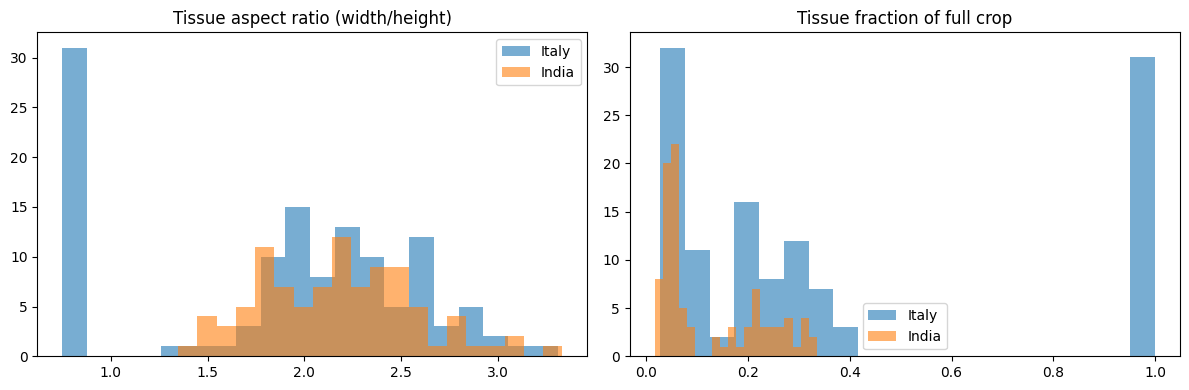

In [ ]:
def measure_tissue_fraction(palpebral_path, black_thresh=15):

    img = robust_load_image(palpebral_path, target_mode='RGB')
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > black_thresh
    total_pixels = mask.size
    tissue_pixels = mask.sum()
    tissue_fraction = tissue_pixels / total_pixels

    if tissue_pixels < 100:
        return {'tissue_fraction': tissue_fraction, 'tissue_aspect_ratio': np.nan, 'tissue_w': 0, 'tissue_h': 0}

    ys, xs = np.where(mask)
    tissue_h = ys.max() - ys.min() + 1
    tissue_w = xs.max() - xs.min() + 1
    tissue_aspect_ratio = tissue_w / tissue_h

    return {'tissue_fraction': tissue_fraction, 'tissue_aspect_ratio': tissue_aspect_ratio,
            'tissue_w': tissue_w, 'tissue_h': tissue_h}

def framing_stats(df):
    results = [measure_tissue_fraction(r['palpebral_path']) for _, r in df.iterrows()]
    return pd.DataFrame(results)

italy_framing = framing_stats(manifest_clean[manifest_clean['Cohort']=='Italy'])
india_framing = framing_stats(manifest_clean[manifest_clean['Cohort']=='India'])

print("=== Italy framing stats ===")
print(italy_framing.describe().loc[['mean','std','min','max']])
print("\n=== India framing stats ===")
print(india_framing.describe().loc[['mean','std','min','max']])

print("\n=== Effect sizes (Italy - India) ===")
for col in ['tissue_fraction', 'tissue_aspect_ratio']:
    diff = italy_framing[col].mean() - india_framing[col].mean()
    pooled_std = np.sqrt((italy_framing[col].std()**2 + india_framing[col].std()**2)/2)
    print(f"{col}: diff={diff:+.3f}, Cohen's d={diff/(pooled_std+1e-6):+.2f}")


fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(italy_framing['tissue_aspect_ratio'].dropna(), bins=20, alpha=0.6, label='Italy')
axes[0].hist(india_framing['tissue_aspect_ratio'].dropna(), bins=20, alpha=0.6, label='India')
axes[0].set_title('Tissue aspect ratio (width/height)'); axes[0].legend()

axes[1].hist(italy_framing['tissue_fraction'], bins=20, alpha=0.6, label='Italy')
axes[1].hist(india_framing['tissue_fraction'], bins=20, alpha=0.6, label='India')
axes[1].set_title('Tissue fraction of full crop'); axes[1].legend()
plt.tight_layout(); plt.savefig(f'{BASE_DIR}/framing_consistency_check.png'); plt.show()

# **7. identifies the 31 full-canvas patients**

In [ ]:
italy_df_check = manifest_clean[manifest_clean['Cohort']=='Italy'].reset_index(drop=True)
italy_framing_indexed = italy_framing.reset_index(drop=True)
full_canvas_patients = italy_df_check[italy_framing_indexed['tissue_fraction'] > 0.9]

print(f"Patients with near-total tissue fraction (full-canvas, no padding): {len(full_canvas_patients)}")
print(full_canvas_patients[['Number','Cohort','Hgb','severity','palpebral_path']].to_string(index=False))

print("\nFilenames of these 31 patients:")
for p in full_canvas_patients['palpebral_path']:
    print(os.path.basename(p))

Patients with near-total tissue fraction (full-canvas, no padding): 31
 Number Cohort   Hgb severity                                   palpebral_path
      1  Italy  9.30 moderate  /content/anemia_local/Italy/1/001_palpebral.png
      2  Italy 10.20 moderate  /content/anemia_local/Italy/2/002_palpebral.png
      3  Italy 10.70 moderate  /content/anemia_local/Italy/3/003_palpebral.png
      4  Italy 11.70     mild  /content/anemia_local/Italy/4/004_palpebral.png
      5  Italy 11.60     mild  /content/anemia_local/Italy/5/005_palpebral.png
      6  Italy 15.00     none  /content/anemia_local/Italy/6/006_palpebral.png
      7  Italy 12.00     none  /content/anemia_local/Italy/7/007_palpebral.png
      8  Italy 14.30     none  /content/anemia_local/Italy/8/008_palpebral.png
      9  Italy  9.80 moderate  /content/anemia_local/Italy/9/009_palpebral.png
     10  Italy 12.20     mild /content/anemia_local/Italy/10/010_palpebral.png
     11  Italy 12.00     none /content/anemia_local/Italy/11

# **8. confirms batch1/batch2 gap**

In [ ]:
batch1_nums = set(range(1, 32))
italy_df_labeled = manifest_clean[manifest_clean['Cohort']=='Italy'].copy()
italy_df_labeled['batch'] = italy_df_labeled['Number'].apply(lambda n: 'batch1_fullcanvas' if n in batch1_nums else 'batch2_padded')

def crop_stats_by_batch(df, batch_label):
    subset = df[df['batch'] == batch_label]
    stats = []
    for _, r in subset.iterrows():
        img = extract_roi(r['palpebral_path'])
        stats.append({'mean_brightness': img.mean(), 'mean_R': img[:,:,0].mean(), 'severity': r['severity_3class']})
    return pd.DataFrame(stats)

batch1_stats = crop_stats_by_batch(italy_df_labeled, 'batch1_fullcanvas')
batch2_stats = crop_stats_by_batch(italy_df_labeled, 'batch2_padded')

print(f"Batch 1 (full-canvas, n={len(batch1_stats)}): mean_brightness={batch1_stats['mean_brightness'].mean():.1f}")
print(f"Batch 2 (padded, n={len(batch2_stats)}): mean_brightness={batch2_stats['mean_brightness'].mean():.1f}")
diff = batch1_stats['mean_brightness'].mean() - batch2_stats['mean_brightness'].mean()
pooled_std = np.sqrt((batch1_stats['mean_brightness'].std()**2 + batch2_stats['mean_brightness'].std()**2)/2)
print(f"Effect size (Cohen's d) after tight-crop: {diff/(pooled_std+1e-6):+.2f}")

print(f"\nSeverity distribution, batch 1: {batch1_stats['severity'].value_counts(normalize=True).to_dict()}")
print(f"Severity distribution, batch 2: {batch2_stats['severity'].value_counts(normalize=True).to_dict()}")

Batch 1 (full-canvas, n=31): mean_brightness=249.6
Batch 2 (padded, n=91): mean_brightness=24.3
Effect size (Cohen's d) after tight-crop: +17.34

Severity distribution, batch 1: {2: 0.41935483870967744, 0: 0.3225806451612903, 1: 0.25806451612903225}
Severity distribution, batch 2: {0: 0.978021978021978, 1: 0.01098901098901099, 2: 0.01098901098901099}


# **9. the visual grid — this is the image that caught the bug**

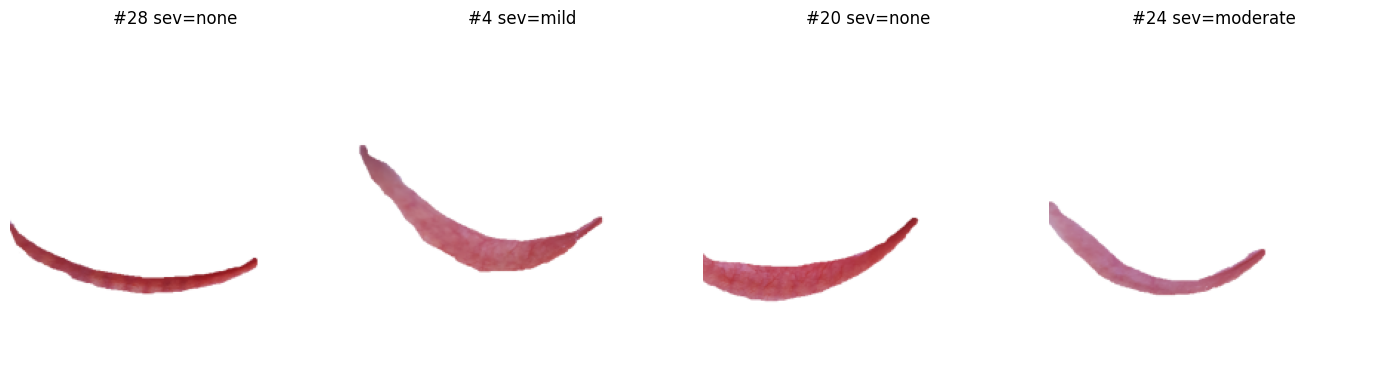

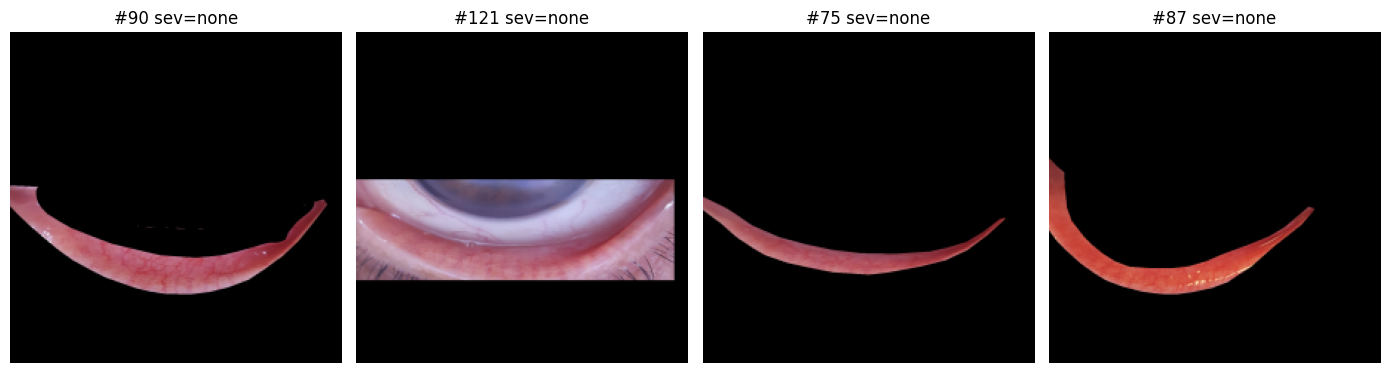

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(14,4))
batch1_samples = italy_df_labeled[italy_df_labeled['batch']=='batch1_fullcanvas'].sample(4, random_state=1)
for ax, (_, r) in zip(axes, batch1_samples.iterrows()):
    img = extract_roi(r['palpebral_path'])
    ax.imshow(img); ax.set_title(f"#{r['Number']} sev={r['severity']}"); ax.axis('off')
plt.tight_layout(); plt.savefig(f'{BASE_DIR}/batch1_inspection.png'); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(14,4))
batch2_samples = italy_df_labeled[italy_df_labeled['batch']=='batch2_padded'].sample(4, random_state=1)
for ax, (_, r) in zip(axes, batch2_samples.iterrows()):
    img = extract_roi(r['palpebral_path'])
    ax.imshow(img); ax.set_title(f"#{r['Number']} sev={r['severity']}"); ax.axis('off')
plt.tight_layout(); plt.savefig(f'{BASE_DIR}/batch2_inspection.png'); plt.show()

# **10. FINAL correct extract_roi**

In [ ]:
italy_df_labeled = manifest_clean[manifest_clean['Cohort']=='Italy'].copy()
italy_df_labeled['batch'] = italy_df_labeled['Number'].apply(lambda n: 'batch1' if n <= 31 else 'batch2')

def crop_stats_tissue_only(df, batch_label):
    subset = df[df['batch'] == batch_label]
    print(f"  [{batch_label}] matched {len(subset)} patients")
    vals = []
    for _, r in subset.iterrows():
        img = robust_load_image(r['palpebral_path'], target_mode='RGB')
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        h, w = gray.shape
        corner_vals = [gray[0,0], gray[0,w-1], gray[h-1,0], gray[h-1,w-1]]
        is_white_bg = np.mean(corner_vals) > 200
        mask = (gray < 240) if is_white_bg else (gray > 15)
        if mask.sum() > 100:
            vals.append(img[mask].mean())
    return np.array(vals)

b1_tissue = crop_stats_tissue_only(italy_df_labeled, 'batch1')
b2_tissue = crop_stats_tissue_only(italy_df_labeled, 'batch2')

if len(b1_tissue) == 0 or len(b2_tissue) == 0:
    print("empty ")
else:
    diff = b1_tissue.mean() - b2_tissue.mean()
    pooled_std = np.sqrt((b1_tissue.std()**2 + b2_tissue.std()**2)/2)
    print(f"TRUE tissue-only brightness -- Batch1: {b1_tissue.mean():.1f}, Batch2: {b2_tissue.mean():.1f}")
    print(f"Cohen's d (tissue pixels only, no background leakage): {diff/(pooled_std+1e-6):+.2f}")

  [batch1] matched 31 patients
  [batch2] matched 91 patients
TRUE tissue-only brightness -- Batch1: 139.1, Batch2: 135.8
Cohen's d (tissue pixels only, no background leakage): +0.18


# **11. Pooled in-domain 5-fold CV (v4: seeded, class-balanced, min_epochs floor)**

In [4]:
def train_one_fold_v4(manifest_df, fold, norm_mode='clahe', epochs=60, batch_size=16, lr=5e-5,
                      lambda_reg=0.5, patience=15, min_epochs=20, num_classes=3, seed=42,
                      use_masking=False):
    torch.manual_seed(seed + fold); np.random.seed(seed + fold)

    train_df = manifest_df[manifest_df['fold'] != fold]
    val_df   = manifest_df[manifest_df['fold'] == fold]
    hgb_mean, hgb_std = get_hgb_stats(train_df)

    train_ds = AnemiaEyeDataset3(train_df, norm_mode=norm_mode, augment=True, use_masking=use_masking)
    val_ds   = AnemiaEyeDataset3(val_df, norm_mode=norm_mode, augment=False, use_masking=use_masking)
    sampler = make_balanced_sampler_3class(train_df)
    train_dl = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=2)
    val_dl   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)

    counts = train_df['severity_3class'].value_counts().reindex(range(num_classes), fill_value=1)
    class_weights = torch.tensor((1.0 / counts.values), dtype=torch.float32)
    class_weights = (class_weights / class_weights.sum() * num_classes).to(device)

    model = AnemiaNet(num_severity_classes=num_classes).to(device)
    opt = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    huber = nn.HuberLoss(delta=1.0)

    best_val_f1, best_state, no_improve = -1, None, 0
    best_val_acc, best_val_mae = None, None
    history = []

    for epoch in range(epochs):
        model.train()
        for batch in train_dl:
            img, meta = batch['image'].to(device), batch['meta'].to(device)
            sev, hgb = batch['severity'].to(device), batch['hgb'].to(device)
            hgb_z = (hgb - hgb_mean) / hgb_std
            opt.zero_grad()
            ord_logits, hgb_pred_z = model(img, meta)
            loss = coral_loss_weighted(ord_logits, sev, num_classes, class_weights) + lambda_reg * huber(hgb_pred_z, hgb_z)
            loss.backward(); opt.step()
        sched.step()

        model.eval()
        val_true, val_pred, val_mae_list = [], [], []
        with torch.no_grad():
            for batch in val_dl:
                img, meta = batch['image'].to(device), batch['meta'].to(device)
                sev, hgb = batch['severity'].to(device), batch['hgb'].to(device)
                ord_logits, hgb_pred_z = model(img, meta)
                hgb_pred = hgb_pred_z * hgb_std + hgb_mean
                pred_sev = CoralOrdinalHead.logits_to_label(ord_logits)
                val_true.extend(sev.cpu().tolist()); val_pred.extend(pred_sev.cpu().tolist())
                val_mae_list.extend(torch.abs(hgb_pred - hgb).cpu().tolist())

        val_macro_f1 = f1_score(val_true, val_pred, average='macro', zero_division=0)
        val_acc = np.mean(np.array(val_true) == np.array(val_pred))
        val_mae = np.mean(val_mae_list)
        history.append({'epoch': epoch, 'val_acc': val_acc, 'val_macro_f1': val_macro_f1, 'val_mae': val_mae})

        if epoch >= min_epochs:
            if val_macro_f1 > best_val_f1:
                best_val_f1, best_state, no_improve = val_macro_f1, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
                best_val_acc, best_val_mae = val_acc, val_mae
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f"  Early stop at epoch {epoch}"); break
        elif val_macro_f1 > best_val_f1:
            best_val_f1, best_state = val_macro_f1, {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_val_acc, best_val_mae = val_acc, val_mae

        if epoch % 5 == 0:
            print(f"Fold {fold} | Epoch {epoch:2d} | val_acc={val_acc:.3f} val_macro_F1={val_macro_f1:.3f} val_MAE={val_mae:.2f}")

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), (hgb_mean, hgb_std), best_val_acc, best_val_f1, best_val_mae

def run_full_cv_v4(manifest_df, norm_mode='clahe', epochs=60, use_masking=False):
    fold_results, models_by_fold = [], {}
    for fold in sorted(manifest_df['fold'].unique()):
        print(f"\n{'='*50}\nFold {fold}\n{'='*50}")
        model, hist, hgb_stats, best_acc, best_f1, best_mae = train_one_fold_v4(
            manifest_df, fold, norm_mode=norm_mode, epochs=epochs, use_masking=use_masking)
        models_by_fold[fold] = (model, hgb_stats)

        fold_results.append({'fold': fold, 'val_acc': best_acc, 'val_macro_f1': best_f1, 'val_mae': best_mae})
        torch.save(model.state_dict(), f'/content/drive/MyDrive/anemia/model_fold{fold}_v4.pt')
    results_df = pd.DataFrame(fold_results)
    print(f"\n=== 5-Fold CV Summary  ===\n{results_df}")
    print(f"Accuracy: {results_df['val_acc'].mean():.3f} +/- {results_df['val_acc'].std():.3f}")
    print(f"Macro-F1: {results_df['val_macro_f1'].mean():.3f} +/- {results_df['val_macro_f1'].std():.3f}")
    print(f"MAE: {results_df['val_mae'].mean():.2f} +/- {results_df['val_mae'].std():.2f}")
    return results_df, models_by_fold

# **12. Cross-domain (Leave-One-Cohort-Out) training + evaluation functions**


In [5]:
def train_full_v4(train_df, norm_mode='clahe', epochs=60, batch_size=16, lr=5e-5,
                  lambda_reg=0.5, num_classes=3, seed=42, use_masking=False):

    torch.manual_seed(seed); np.random.seed(seed)
    hgb_mean, hgb_std = get_hgb_stats(train_df)

    train_ds = AnemiaEyeDataset3(train_df, norm_mode=norm_mode, augment=True, use_masking=use_masking)
    sampler = make_balanced_sampler_3class(train_df)
    train_dl = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=2)

    counts = train_df['severity_3class'].value_counts().reindex(range(num_classes), fill_value=1)
    class_weights = torch.tensor((1.0 / counts.values), dtype=torch.float32)
    class_weights = (class_weights / class_weights.sum() * num_classes).to(device)

    model = AnemiaNet(num_severity_classes=num_classes).to(device)
    opt = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    huber = nn.HuberLoss(delta=1.0)

    for epoch in range(epochs):
        model.train()
        for batch in train_dl:
            img, meta = batch['image'].to(device), batch['meta'].to(device)
            sev, hgb = batch['severity'].to(device), batch['hgb'].to(device)
            hgb_z = (hgb - hgb_mean) / hgb_std
            opt.zero_grad()
            ord_logits, hgb_pred_z = model(img, meta)
            loss = coral_loss_weighted(ord_logits, sev, num_classes, class_weights) + lambda_reg * huber(hgb_pred_z, hgb_z)
            loss.backward(); opt.step()
        sched.step()
        if epoch % 10 == 0:
            print(f"  epoch {epoch}: train loss={loss.item():.3f}")
    return model, (hgb_mean, hgb_std)

def evaluate_v4(model, eval_df, hgb_stats, norm_mode='clahe', batch_size=16, use_masking=False):
    hgb_mean, hgb_std = hgb_stats
    eval_ds = AnemiaEyeDataset3(eval_df, norm_mode=norm_mode, augment=False, use_masking=use_masking)
    eval_dl = DataLoader(eval_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    model.eval()
    correct, mae_sum, n = 0, 0, 0
    all_true, all_pred = [], []
    with torch.no_grad():
        for batch in eval_dl:
            img, meta = batch['image'].to(device), batch['meta'].to(device)
            sev, hgb = batch['severity'].to(device), batch['hgb'].to(device)
            ord_logits, hgb_pred_z = model(img, meta)
            hgb_pred = hgb_pred_z * hgb_std + hgb_mean
            pred_sev = CoralOrdinalHead.logits_to_label(ord_logits)
            correct += (pred_sev == sev).sum().item()
            mae_sum += torch.abs(hgb_pred - hgb).sum().item()
            n += img.size(0)
            all_true.extend(sev.cpu().tolist()); all_pred.extend(pred_sev.cpu().tolist())
    return {'accuracy': correct/n, 'mae': mae_sum/n, 'n': n, 'y_true': all_true, 'y_pred': all_pred}

print("LOCO functions loaded.")

LOCO functions loaded.


# **13. preprocess_roi**

In [ ]:
def preprocess_roi_exp(img_rgb, mode='clahe'):
    img_rgb = normalize_exposure(img_rgb)
    if mode == 'clahe':
        return apply_clahe(img_rgb)
    return img_rgb

print("=== Retraining Italy model with exposure-normalized preprocessing ===")
_original_preprocess_roi = preprocess_roi
preprocess_roi = preprocess_roi_exp
model_it2in_exposure, hgb_stats_exp = train_full_v4(manifest_clean[manifest_clean['Cohort']=='Italy'], epochs=60)
result_exposure = evaluate_v4(model_it2in_exposure, manifest_clean[manifest_clean['Cohort']=='India'], hgb_stats_exp)
preprocess_roi = _original_preprocess_roi

f1_exposure = f1_score(result_exposure['y_true'], result_exposure['y_pred'], average='macro', zero_division=0)
print(f"\nItaly->India, WITH exposure normalization: Accuracy={result_exposure['accuracy']:.3f}, macro-F1={f1_exposure:.3f}")
print(f"Italy->India, WITHOUT (original): macro-F1=0.265-0.300")
print(confusion_matrix(result_exposure['y_true'], result_exposure['y_pred']))

=== Retraining Italy model with exposure-normalized preprocessing ===
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 129MB/s]


  epoch 0: train loss=1.014
  epoch 10: train loss=0.731
  epoch 20: train loss=0.502
  epoch 30: train loss=0.704
  epoch 40: train loss=0.676
  epoch 50: train loss=1.025

Italy->India, WITH exposure normalization: Accuracy=0.274, macro-F1=0.160
Italy->India, WITHOUT (original): macro-F1=0.265-0.300
[[25  1  1]
 [26  0  2]
 [37  2  1]]


# **14. Main result**

In [6]:
print("=== Pooled 5-fold CV (background-corrected) ===")
cv_results_final, cv_models_final = run_full_cv_v4(manifest_clean, epochs=60)

print("\n=== LOCO: Italy -> India (background-corrected) ===")
model_it2in_final, hgb_stats_it_final = train_full_v4(manifest_clean[manifest_clean['Cohort']=='Italy'], epochs=60)
result_it2in_final = evaluate_v4(model_it2in_final, manifest_clean[manifest_clean['Cohort']=='India'], hgb_stats_it_final)
f1_it2in_final = f1_score(result_it2in_final['y_true'], result_it2in_final['y_pred'], average='macro', zero_division=0)
print(f"Accuracy: {result_it2in_final['accuracy']:.3f}, macro-F1: {f1_it2in_final:.3f}")
print(confusion_matrix(result_it2in_final['y_true'], result_it2in_final['y_pred']))

print("\n=== LOCO: India -> Italy (background-corrected) ===")
model_in2it_final, hgb_stats_in_final = train_full_v4(manifest_clean[manifest_clean['Cohort']=='India'], epochs=60)
result_in2it_final = evaluate_v4(model_in2it_final, manifest_clean[manifest_clean['Cohort']=='Italy'], hgb_stats_in_final)
f1_in2it_final = f1_score(result_in2it_final['y_true'], result_in2it_final['y_pred'], average='macro', zero_division=0)
print(f"Accuracy: {result_in2it_final['accuracy']:.3f}, macro-F1: {f1_in2it_final:.3f}")
print(confusion_matrix(result_in2it_final['y_true'], result_in2it_final['y_pred']))

for m, name in [(cv_models_final, 'pooled'), (model_it2in_final, 'it2in'), (model_in2it_final, 'in2it')]:
    pass
torch.save(model_it2in_final.state_dict(), '/content/drive/MyDrive/anemia/model_it2in_FINAL.pt')
torch.save(model_in2it_final.state_dict(), '/content/drive/MyDrive/anemia/model_in2it_FINAL.pt')

=== Pooled 5-fold CV (background-corrected) ===

Fold 0
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 128MB/s]


Fold 0 | Epoch  0 | val_acc=0.250 val_macro_F1=0.133 val_MAE=1.89
Fold 0 | Epoch  5 | val_acc=0.273 val_macro_F1=0.143 val_MAE=1.85
Fold 0 | Epoch 10 | val_acc=0.273 val_macro_F1=0.143 val_MAE=1.89
Fold 0 | Epoch 15 | val_acc=0.432 val_macro_F1=0.317 val_MAE=1.65
Fold 0 | Epoch 20 | val_acc=0.614 val_macro_F1=0.450 val_MAE=1.56
Fold 0 | Epoch 25 | val_acc=0.636 val_macro_F1=0.462 val_MAE=1.46
Fold 0 | Epoch 30 | val_acc=0.659 val_macro_F1=0.476 val_MAE=1.37
Fold 0 | Epoch 35 | val_acc=0.682 val_macro_F1=0.491 val_MAE=1.35
  Early stop at epoch 39

Fold 1
Fold 1 | Epoch  0 | val_acc=0.250 val_macro_F1=0.133 val_MAE=2.19
Fold 1 | Epoch  5 | val_acc=0.250 val_macro_F1=0.133 val_MAE=2.21
Fold 1 | Epoch 10 | val_acc=0.273 val_macro_F1=0.163 val_MAE=2.13
Fold 1 | Epoch 15 | val_acc=0.455 val_macro_F1=0.331 val_MAE=1.93
Fold 1 | Epoch 20 | val_acc=0.659 val_macro_F1=0.470 val_MAE=1.87
Fold 1 | Epoch 25 | val_acc=0.682 val_macro_F1=0.485 val_MAE=1.75
Fold 1 | Epoch 30 | val_acc=0.750 val_macro

# **14.b Multi‑seed training (3 seeds)**

In [ ]:
seeds = [42, 123, 2024]
cv_results_by_seed = []
loco_it2in_by_seed = []
loco_in2it_by_seed = []

for seed in seeds:
    print(f"\n{'#'*20} Seed {seed} {'#'*20}")

    torch.manual_seed(seed)
    np.random.seed(seed)

    cv_res, cv_models = run_full_cv_v4(manifest_clean, epochs=60)
    cv_res['seed'] = seed
    cv_results_by_seed.append(cv_res)

    # LOCO Italy -> India
    model_it, hgb_it = train_full_v4(manifest_clean[manifest_clean['Cohort']=='Italy'],
                                      epochs=60, seed=seed)
    res_it2in = evaluate_v4(model_it, manifest_clean[manifest_clean['Cohort']=='India'],
                            hgb_it)
    f1_it2in = f1_score(res_it2in['y_true'], res_it2in['y_pred'], average='macro', zero_division=0)
    loco_it2in_by_seed.append({'seed': seed, 'accuracy': res_it2in['accuracy'],
                               'macro_f1': f1_it2in, 'mae': res_it2in['mae']})

    # LOCO India -> Italy
    model_in, hgb_in = train_full_v4(manifest_clean[manifest_clean['Cohort']=='India'],
                                      epochs=60, seed=seed)
    res_in2it = evaluate_v4(model_in, manifest_clean[manifest_clean['Cohort']=='Italy'],
                            hgb_in)
    f1_in2it = f1_score(res_in2it['y_true'], res_in2it['y_pred'], average='macro', zero_division=0)
    loco_in2it_by_seed.append({'seed': seed, 'accuracy': res_in2it['accuracy'],
                               'macro_f1': f1_in2it, 'mae': res_in2it['mae']})


    if seed == 42:
        cv_results_final = cv_res
        cv_models_final = cv_models
        model_it2in_final = model_it
        hgb_stats_it_final = hgb_it
        model_in2it_final = model_in
        hgb_stats_in_final = hgb_in
        f1_it2in = f1_it2in
        f1_in2it = f1_in2it
        result_it2in_final = res_it2in
        result_in2it_final = res_in2it


#################### Seed 42 ####################

Fold 0
Fold 0 | Epoch  0 | val_acc=0.250 val_macro_F1=0.133 val_MAE=1.87
Fold 0 | Epoch  5 | val_acc=0.273 val_macro_F1=0.143 val_MAE=1.86
Fold 0 | Epoch 10 | val_acc=0.273 val_macro_F1=0.143 val_MAE=1.80
Fold 0 | Epoch 15 | val_acc=0.568 val_macro_F1=0.419 val_MAE=1.61
Fold 0 | Epoch 20 | val_acc=0.659 val_macro_F1=0.475 val_MAE=1.53
Fold 0 | Epoch 25 | val_acc=0.659 val_macro_F1=0.471 val_MAE=1.43
Fold 0 | Epoch 30 | val_acc=0.659 val_macro_F1=0.476 val_MAE=1.38
Fold 0 | Epoch 35 | val_acc=0.682 val_macro_F1=0.485 val_MAE=1.40
Fold 0 | Epoch 40 | val_acc=0.682 val_macro_F1=0.491 val_MAE=1.40
Fold 0 | Epoch 45 | val_acc=0.705 val_macro_F1=0.500 val_MAE=1.32
Fold 0 | Epoch 50 | val_acc=0.705 val_macro_F1=0.500 val_MAE=1.33
Fold 0 | Epoch 55 | val_acc=0.705 val_macro_F1=0.500 val_MAE=1.32
  Early stop at epoch 56

Fold 1
Fold 1 | Epoch  0 | val_acc=0.273 val_macro_F1=0.143 val_MAE=2.18
Fold 1 | Epoch  5 | val_acc=0.273 val_macro_F1=0.1

# **14.c Summary of multi-seed results**

In [ ]:
cv_df = pd.DataFrame([{'seed': r['seed'], 'acc': r['val_acc'].mean(),
                       'f1': r['val_macro_f1'].mean()}
                      for r in cv_results_by_seed])
print("=== Pooled CV across seeds ===")
print(cv_df)
print(f"Mean accuracy: {cv_df['acc'].mean():.3f} ± {cv_df['acc'].std():.3f}")
print(f"Mean macro-F1: {cv_df['f1'].mean():.3f} ± {cv_df['f1'].std():.3f}")

loco_df = pd.DataFrame(loco_it2in_by_seed)
print("\n=== Italy → India LOCO ===")
print(loco_df)
print(f"Mean macro-F1: {loco_df['macro_f1'].mean():.3f} ± {loco_df['macro_f1'].std():.3f}")

loco_df2 = pd.DataFrame(loco_in2it_by_seed)
print("\n=== India → Italy LOCO ===")
print(loco_df2)
print(f"Mean macro-F1: {loco_df2['macro_f1'].mean():.3f} ± {loco_df2['macro_f1'].std():.3f}")

# **14.d  Save all multi-seed results to Drive**

In [ ]:
import pickle

save_dict = {
    'seeds': seeds,
    'cv_results_by_seed': cv_results_by_seed,
    'loco_it2in_by_seed': loco_it2in_by_seed,
    'loco_in2it_by_seed': loco_in2it_by_seed,
    'cv_results_final': cv_results_final,
    'loco_it2in_final': loco_it2in_by_seed[0],   # seed 42
    'loco_in2it_final': loco_in2it_by_seed[0],
}
with open('/content/drive/MyDrive/anemia/multi_seed_results.pkl', 'wb') as f:
    pickle.dump(save_dict, f)
print("Saved multi-seed results to Drive.")

# **15. few shot**

In [ ]:
from sklearn.model_selection import train_test_split
import copy
def few_shot_calibrate(base_model, target_train_subset, hgb_stats, epochs=20, lr=1e-5, num_classes=3):

    model = copy.deepcopy(base_model)
    hgb_mean, hgb_std = hgb_stats
    ds = AnemiaEyeDataset3(target_train_subset, norm_mode='clahe', augment=True)
    dl = DataLoader(ds, batch_size=min(8, len(ds)), shuffle=True)
    opt = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    huber = nn.HuberLoss(delta=1.0)
    counts = target_train_subset['severity_3class'].value_counts().reindex(range(num_classes), fill_value=1)
    class_weights = torch.tensor((1.0/counts.values), dtype=torch.float32)
    class_weights = (class_weights/class_weights.sum()*num_classes).to(device)

    model.train()
    for epoch in range(epochs):
        for batch in dl:
            img, meta = batch['image'].to(device), batch['meta'].to(device)
            sev, hgb = batch['severity'].to(device), batch['hgb'].to(device)
            hgb_z = (hgb - hgb_mean) / hgb_std
            opt.zero_grad()
            ord_logits, hgb_pred_z = model(img, meta)
            loss = coral_loss_weighted(ord_logits, sev, num_classes, class_weights) + 0.5*huber(hgb_pred_z, hgb_z)
            loss.backward(); opt.step()
    return model


india_full = manifest_clean[manifest_clean['Cohort']=='India'].copy()
shot_sizes = [0, 5, 10, 15, 20]
curve_results = []

for n_shots in shot_sizes:
    if n_shots == 0:
        model_variant = model_it2in_final
        test_subset = india_full
    else:

        calib_subset, test_subset = train_test_split(
            india_full, train_size=n_shots, random_state=42,
            stratify=india_full['severity_3class']
        )
        model_variant = few_shot_calibrate(model_it2in_final, calib_subset, hgb_stats_it_final)

    result = evaluate_v4(model_variant, test_subset, hgb_stats_it_final)
    f1 = f1_score(result['y_true'], result['y_pred'], average='macro', zero_division=0)
    curve_results.append({'n_shots': n_shots, 'test_n': len(test_subset), 'accuracy': result['accuracy'], 'macro_f1': f1})
    print(f"n_shots={n_shots}: test_n={len(test_subset)}, accuracy={result['accuracy']:.3f}, macro-F1={f1:.3f}")

curve_df = pd.DataFrame(curve_results)
print(f"\n{curve_df}")

plt.figure(figsize=(7,5))
plt.plot(curve_df['n_shots'], curve_df['macro_f1'], marker='o')
plt.axhline(0.490, color='gray', linestyle='--', label='pooled in-domain ceiling')
plt.xlabel('Number of labeled India patients used for calibration')
plt.ylabel('Macro-F1 on held-out India patients')
plt.title('Few-shot target-domain calibration curve')
plt.legend(); plt.savefig(f'{BASE_DIR}/few_shot_curve.png'); plt.show()
curve_df.to_csv('/content/drive/MyDrive/anemia/few_shot_calibration_curve.csv', index=False)

# **16. age, gender**

In [ ]:
print("=== Age distribution by cohort ===")
print(manifest_clean.groupby('Cohort')['Age'].describe()[['mean','std','min','max']])
print("\n=== Gender distribution by cohort ===")
print(pd.crosstab(manifest_clean['Cohort'], manifest_clean['Gender'], normalize='index'))

class AnemiaEyeDataset3NoMeta(AnemiaEyeDataset3):
    def __getitem__(self, idx):
        item = super().__getitem__(idx)
        item['meta'] = torch.zeros_like(item['meta'])
        return item

def train_full_v4_nometa(train_df, norm_mode='clahe', epochs=60, batch_size=16, lr=5e-5,
                           lambda_reg=0.5, num_classes=3, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    hgb_mean, hgb_std = get_hgb_stats(train_df)
    train_ds = AnemiaEyeDataset3NoMeta(train_df, norm_mode=norm_mode, augment=True)
    sampler = make_balanced_sampler_3class(train_df)
    train_dl = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=2)
    counts = train_df['severity_3class'].value_counts().reindex(range(num_classes), fill_value=1)
    class_weights = torch.tensor((1.0/counts.values), dtype=torch.float32)
    class_weights = (class_weights / class_weights.sum() * num_classes).to(device)
    model = AnemiaNet(num_severity_classes=num_classes).to(device)
    opt = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    huber = nn.HuberLoss(delta=1.0)
    for epoch in range(epochs):
        model.train()
        for batch in train_dl:
            img, meta = batch['image'].to(device), batch['meta'].to(device)
            sev, hgb = batch['severity'].to(device), batch['hgb'].to(device)
            hgb_z = (hgb - hgb_mean) / hgb_std
            opt.zero_grad()
            ord_logits, hgb_pred_z = model(img, meta)
            loss = coral_loss_weighted(ord_logits, sev, num_classes, class_weights) + lambda_reg * huber(hgb_pred_z, hgb_z)
            loss.backward(); opt.step()
        sched.step()
    return model, (hgb_mean, hgb_std)

def evaluate_v4_nometa(model, eval_df, hgb_stats, norm_mode='clahe', batch_size=16):
    hgb_mean, hgb_std = hgb_stats
    eval_ds = AnemiaEyeDataset3NoMeta(eval_df, norm_mode=norm_mode, augment=False)
    eval_dl = DataLoader(eval_ds, batch_size=batch_size, shuffle=False)
    model.eval()
    correct, n = 0, 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in eval_dl:
            img, meta = batch['image'].to(device), batch['meta'].to(device)
            sev = batch['severity'].to(device)
            ord_logits, _ = model(img, meta)
            pred_sev = CoralOrdinalHead.logits_to_label(ord_logits)
            correct += (pred_sev == sev).sum().item(); n += img.size(0)
            y_true.extend(sev.cpu().tolist()); y_pred.extend(pred_sev.cpu().tolist())
    return {'accuracy': correct/n, 'y_true': y_true, 'y_pred': y_pred}

print("\n=== Retraining Italy->India with metadata ZEROED (image-only signal) ===")
model_nometa, hgb_stats_nometa = train_full_v4_nometa(manifest_clean[manifest_clean['Cohort']=='Italy'], epochs=60)
result_nometa = evaluate_v4_nometa(model_nometa, manifest_clean[manifest_clean['Cohort']=='India'], hgb_stats_nometa)
f1_nometa = f1_score(result_nometa['y_true'], result_nometa['y_pred'], average='macro', zero_division=0)

print(f"\nWithout metadata (image-only): Accuracy={result_nometa['accuracy']:.3f}, macro-F1={f1_nometa:.3f}")
print(f"With metadata (original, background-corrected): Accuracy=0.326, macro-F1=0.251")

# **17. fusion**

In [ ]:
class AnemiaEyeDatasetFusion(Dataset):
    def __init__(self, df, norm_mode='clahe', augment=False, img_size=224):

        self.df = df[df['has_forniceal']].reset_index(drop=True)
        self.norm_mode = norm_mode
        self.gender_map = {'M': 0, 'F': 1}
        aug = []
        if augment:
            aug += [T.RandomHorizontalFlip(0.5), T.RandomRotation(10), T.ColorJitter(0.1, 0.1)]
        aug += [T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])]
        self.transform = T.Compose(aug)
        self.img_size = img_size
        print(f"Fusion dataset: {len(self.df)} patients (dropped {len(df) - len(self.df)} missing forniceal)")

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        roi_p = preprocess_roi(extract_roi(r['palpebral_path'], (self.img_size, self.img_size)), self.norm_mode)
        roi_f = preprocess_roi(extract_roi(r['forniceal_path'], (self.img_size, self.img_size)), self.norm_mode)
        img_p = self.transform(Image.fromarray(roi_p))
        img_f = self.transform(Image.fromarray(roi_f))
        meta_t = torch.tensor([float(r['Age'])/100.0, float(self.gender_map.get(r['Gender'],0))], dtype=torch.float32)
        return {'image_p': img_p, 'image_f': img_f, 'meta': meta_t,
                'severity': torch.tensor(int(r['severity_3class']), dtype=torch.long),
                'hgb': torch.tensor(float(r['Hgb']), dtype=torch.float32),
                'cohort': r['Cohort'], 'patient_id': int(r['Number'])}

class AnemiaNetFusion(nn.Module):

    def __init__(self, num_severity_classes=3, meta_dim=2, pretrained=True):
        super().__init__()
        base = models.mobilenet_v3_small(weights='IMAGENET1K_V1' if pretrained else None)
        self.feat_dim = base.classifier[0].in_features
        base.classifier = nn.Identity()
        self.backbone = base

        self.fusion = nn.Sequential(nn.Linear(self.feat_dim * 2 + meta_dim, 128), nn.ReLU(), nn.Dropout(0.3))
        self.ordinal_head = CoralOrdinalHead(128, num_severity_classes)
        self.regression_head = nn.Linear(128, 1)

    def forward(self, image_p, image_f, meta):
        feat_p = self.backbone(image_p)
        feat_f = self.backbone(image_f)
        if feat_p.ndim > 2: feat_p = feat_p.flatten(1)
        if feat_f.ndim > 2: feat_f = feat_f.flatten(1)
        fused = self.fusion(torch.cat([feat_p, feat_f, meta], dim=1))
        return self.ordinal_head(fused), self.regression_head(fused).squeeze(-1)

def train_full_fusion(train_df, norm_mode='clahe', epochs=60, batch_size=16, lr=5e-5,
                        lambda_reg=0.5, num_classes=3, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    hgb_mean, hgb_std = get_hgb_stats(train_df[train_df['has_forniceal']])

    train_ds = AnemiaEyeDatasetFusion(train_df, norm_mode=norm_mode, augment=True)
    counts = train_ds.df['severity_3class'].value_counts()
    weights = train_ds.df['severity_3class'].map(lambda c: 1.0/counts[c]).values
    sampler = WeightedRandomSampler(weights, num_samples=len(train_ds), replacement=True)
    train_dl = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=2)

    class_weights = torch.tensor((1.0/counts.reindex(range(num_classes), fill_value=1).values), dtype=torch.float32)
    class_weights = (class_weights / class_weights.sum() * num_classes).to(device)

    model = AnemiaNetFusion(num_severity_classes=num_classes).to(device)
    opt = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    huber = nn.HuberLoss(delta=1.0)

    for epoch in range(epochs):
        model.train()
        for batch in train_dl:
            img_p, img_f = batch['image_p'].to(device), batch['image_f'].to(device)
            meta = batch['meta'].to(device)
            sev, hgb = batch['severity'].to(device), batch['hgb'].to(device)
            hgb_z = (hgb - hgb_mean) / hgb_std
            opt.zero_grad()
            ord_logits, hgb_pred_z = model(img_p, img_f, meta)
            loss = coral_loss_weighted(ord_logits, sev, num_classes, class_weights) + lambda_reg * huber(hgb_pred_z, hgb_z)
            loss.backward(); opt.step()
        sched.step()
        if epoch % 10 == 0: print(f"  epoch {epoch}: loss={loss.item():.3f}")
    return model, (hgb_mean, hgb_std)

def evaluate_fusion(model, eval_df, hgb_stats, norm_mode='clahe', batch_size=16):
    hgb_mean, hgb_std = hgb_stats
    eval_ds = AnemiaEyeDatasetFusion(eval_df, norm_mode=norm_mode, augment=False)
    eval_dl = DataLoader(eval_ds, batch_size=batch_size, shuffle=False)
    model.eval()
    correct, mae_sum, n = 0, 0, 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in eval_dl:
            img_p, img_f = batch['image_p'].to(device), batch['image_f'].to(device)
            meta = batch['meta'].to(device)
            sev, hgb = batch['severity'].to(device), batch['hgb'].to(device)
            ord_logits, hgb_pred_z = model(img_p, img_f, meta)
            hgb_pred = hgb_pred_z * hgb_std + hgb_mean
            pred_sev = CoralOrdinalHead.logits_to_label(ord_logits)
            correct += (pred_sev == sev).sum().item()
            mae_sum += torch.abs(hgb_pred - hgb).sum().item()
            n += img_p.size(0)
            y_true.extend(sev.cpu().tolist()); y_pred.extend(pred_sev.cpu().tolist())
    return {'accuracy': correct/n, 'mae': mae_sum/n, 'n': n, 'y_true': y_true, 'y_pred': y_pred}


print("=== Fusion model: Train Italy -> Test India ===")
model_fusion_it2in, hgb_stats_fusion = train_full_fusion(manifest_clean[manifest_clean['Cohort']=='Italy'], epochs=60)
result_fusion = evaluate_fusion(model_fusion_it2in, manifest_clean[manifest_clean['Cohort']=='India'], hgb_stats_fusion)
f1_fusion = f1_score(result_fusion['y_true'], result_fusion['y_pred'], average='macro', zero_division=0)

print(f"\nFusion (palpebral+forniceal), Italy->India: Accuracy={result_fusion['accuracy']:.3f}, macro-F1={f1_fusion:.3f}")
print(f"Single-region (palpebral only), Italy->India: macro-F1=0.265-0.300 (for comparison)")
print(confusion_matrix(result_fusion['y_true'], result_fusion['y_pred']))

# **18. extract_deep_features, needed for CORAL**

In [ ]:
from scipy.linalg import fractional_matrix_power

def extract_deep_features(model, df, norm_mode='clahe', batch_size=16):
    ds = AnemiaEyeDataset3(df, norm_mode=norm_mode, augment=False)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)
    model.eval()
    feats, labels = [], []
    with torch.no_grad():
        for batch in dl:
            img, meta = batch['image'].to(device), batch['meta'].to(device)
            f = model.backbone(img)
            if f.ndim > 2:
                f = f.flatten(1)
            fused = torch.cat([f, meta], dim=1)
            feats.append(fused.cpu().numpy())
            labels.extend(batch['severity'].tolist())
    return np.concatenate(feats), np.array(labels)

def coral_align(source_feats, target_feats, eps=1e-5):
    def cov(X):
        X = X - X.mean(0, keepdims=True)
        return (X.T @ X) / (X.shape[0] - 1) + eps * np.eye(X.shape[1])
    Cs, Ct = cov(source_feats), cov(target_feats)
    Cs_inv_sqrt = fractional_matrix_power(Cs, -0.5).real
    Ct_sqrt = fractional_matrix_power(Ct, 0.5).real
    source_centered = source_feats - source_feats.mean(0, keepdims=True)
    aligned = source_centered @ Cs_inv_sqrt @ Ct_sqrt
    return aligned + target_feats.mean(0, keepdims=True)

italy_df = manifest_clean[manifest_clean['Cohort']=='Italy']
india_df = manifest_clean[manifest_clean['Cohort']=='India']

italy_feats, italy_labels = extract_deep_features(model_it2in_final, italy_df)
india_feats, india_labels = extract_deep_features(model_it2in_final, india_df)

print(f"Italy features: {italy_feats.shape}, India features: {india_feats.shape}")

italy_feats_aligned = coral_align(italy_feats, india_feats)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

clf_raw = LogisticRegression(max_iter=1000, class_weight='balanced').fit(italy_feats, italy_labels)
pred_raw = clf_raw.predict(india_feats)
f1_raw = f1_score(india_labels, pred_raw, average='macro', zero_division=0)

clf_aligned = LogisticRegression(max_iter=1000, class_weight='balanced').fit(italy_feats_aligned, italy_labels)
pred_aligned = clf_aligned.predict(india_feats)
f1_aligned = f1_score(india_labels, pred_aligned, average='macro', zero_division=0)

print(f"\n=== Deep-feature CORAL alignment: Italy -> India ===")
print(f"Without CORAL (raw deep features): macro-F1 = {f1_raw:.3f}")
print(f"With CORAL (aligned deep features): macro-F1 = {f1_aligned:.3f}")

print("\nDetailed report (CORAL-aligned):")
print(classification_report(india_labels, pred_aligned, target_names=['none','mild','moderate+'], zero_division=0))

# **19. Deep-CORAL feature alignment**

In [ ]:
def deep_coral_loss_v2(source_feat, target_feat, eps=1e-5):
    d = source_feat.size(1)
    if source_feat.size(0) < 2 or target_feat.size(0) < 2:
        return torch.tensor(0.0, device=source_feat.device)
    src = (source_feat - source_feat.mean(0, keepdim=True)) / (source_feat.std(0, keepdim=True) + eps)
    tgt = (target_feat - target_feat.mean(0, keepdim=True)) / (target_feat.std(0, keepdim=True) + eps)
    src_c = torch.cov(src.T)
    tgt_c = torch.cov(tgt.T)
    return ((src_c - tgt_c) ** 2).sum() / (d * d)

def train_full_v4_domain_aligned_v2(train_df, unlabeled_target_df, norm_mode='clahe', epochs=60,
                                       batch_size=16, lr=5e-5, lambda_reg=0.5, lambda_align=1.0,
                                       num_classes=3, seed=42, verbose_scale_check=False):
    torch.manual_seed(seed); np.random.seed(seed)
    hgb_mean, hgb_std = get_hgb_stats(train_df)

    train_ds = AnemiaEyeDataset3(train_df, norm_mode=norm_mode, augment=True)
    target_ds = AnemiaEyeDataset3(unlabeled_target_df, norm_mode=norm_mode, augment=False)
    sampler = make_balanced_sampler_3class(train_df)
    train_dl = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=2)
    target_dl = DataLoader(target_ds, batch_size=batch_size, shuffle=True, num_workers=2)

    counts = train_df['severity_3class'].value_counts().reindex(range(num_classes), fill_value=1)
    class_weights = torch.tensor((1.0 / counts.values), dtype=torch.float32)
    class_weights = (class_weights / class_weights.sum() * num_classes).to(device)

    model = AnemiaNet(num_severity_classes=num_classes).to(device)
    opt = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    huber = nn.HuberLoss(delta=1.0)

    def get_fused_features(m, img, meta):
        feat = m.backbone(img)
        if feat.ndim > 2: feat = feat.flatten(1)
        return m.fusion(torch.cat([feat, meta], dim=1))

    for epoch in range(epochs):
        model.train()
        target_iter = iter(target_dl)
        for step, batch in enumerate(train_dl):
            try:
                tgt_batch = next(target_iter)
            except StopIteration:
                target_iter = iter(target_dl)
                tgt_batch = next(target_iter)

            img, meta = batch['image'].to(device), batch['meta'].to(device)
            sev, hgb = batch['severity'].to(device), batch['hgb'].to(device)
            tgt_img, tgt_meta = tgt_batch['image'].to(device), tgt_batch['meta'].to(device)
            hgb_z = (hgb - hgb_mean) / hgb_std

            opt.zero_grad()
            src_fused = get_fused_features(model, img, meta)
            tgt_fused = get_fused_features(model, tgt_img, tgt_meta)
            ord_logits = model.ordinal_head(src_fused)
            hgb_pred_z = model.regression_head(src_fused).squeeze(-1)

            task_loss = coral_loss_weighted(ord_logits, sev, num_classes, class_weights) + lambda_reg * huber(hgb_pred_z, hgb_z)
            align_loss = deep_coral_loss_v2(src_fused, tgt_fused)
            if verbose_scale_check and epoch == 0 and step == 0:
                print(f"    [scale check] task_loss={task_loss.item():.4f}, raw align_loss={align_loss.item():.4f} ")
            loss = task_loss + lambda_align * align_loss
            loss.backward(); opt.step()
        sched.step()
        if epoch % 10 == 0:
            print(f"  epoch {epoch}: task_loss={task_loss.item():.3f}, align_loss={align_loss.item():.4f}, "
                  f"weighted_align_contrib={lambda_align*align_loss.item():.4f}")
    return model, (hgb_mean, hgb_std)

italy_full = manifest_clean[manifest_clean['Cohort']=='Italy']
india_full = manifest_clean[manifest_clean['Cohort']=='India']

results_by_lambda_v2 = []
for lam in [0.0, 1.0, 10.0, 50.0]:
    print(f"\n{'='*20} lambda_align={lam} (v2) {'='*20}")
    m, hs = train_full_v4_domain_aligned_v2(italy_full, india_full, epochs=60, lambda_align=lam,
                                               verbose_scale_check=(lam==1.0))
    res = evaluate_v4(m, india_full, hs)
    f1 = f1_score(res['y_true'], res['y_pred'], average='macro', zero_division=0)
    print(f"lambda_align={lam}: accuracy={res['accuracy']:.3f}, macro-F1={f1:.3f}")
    results_by_lambda_v2.append({'lambda_align': lam, 'accuracy': res['accuracy'], 'macro_f1': f1})

align_summary_v2 = pd.DataFrame(results_by_lambda_v2)
align_summary_v2.to_csv('/content/drive/MyDrive/anemia/domain_alignment_sweep_v6.csv', index=False)
print(f"\n{align_summary_v2}")


# **19.b Head-only fine-tuning on target domain**

In [ ]:
def head_only_finetune(model, target_train_df, hgb_stats,
                       epochs=20, lr=1e-4, num_classes=3):
    """Freeze backbone, fine-tune fusion+heads on target data."""
    for param in model.backbone.parameters():
        param.requires_grad = False

    opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=1e-4)
    hgb_mean, hgb_std = hgb_stats
    ds = AnemiaEyeDataset3(target_train_df, norm_mode='clahe', augment=True)
    dl = DataLoader(ds, batch_size=min(8, len(ds)), shuffle=True)
    huber = nn.HuberLoss(delta=1.0)
    counts = target_train_df['severity_3class'].value_counts().reindex(range(num_classes), fill_value=1)
    class_weights = torch.tensor((1.0/counts.values), dtype=torch.float32)
    class_weights = (class_weights/class_weights.sum()*num_classes).to(device)
    model.train()
    for epoch in range(epochs):
        for batch in dl:
            img, meta = batch['image'].to(device), batch['meta'].to(device)
            sev, hgb = batch['severity'].to(device), batch['hgb'].to(device)
            hgb_z = (hgb - hgb_mean) / hgb_std
            opt.zero_grad()
            ord_logits, hgb_pred_z = model(img, meta)
            loss = coral_loss_weighted(ord_logits, sev, num_classes, class_weights) + 0.5*huber(hgb_pred_z, hgb_z)
            loss.backward()
            opt.step()
        if epoch % 5 == 0:
            print(f"  Head fine-tune epoch {epoch}: loss={loss.item():.3f}")
    return model


from sklearn.model_selection import train_test_split
india_train_subset, _ = train_test_split(india_df, train_size=20,
                                         stratify=india_df['severity_3class'], random_state=42)
model_finetuned = head_only_finetune(model_it2in_final, india_train_subset, hgb_stats_it_final)
res_finetuned = evaluate_v4(model_finetuned, india_df, hgb_stats_it_final)
f1_finetuned = f1_score(res_finetuned['y_true'], res_finetuned['y_pred'],
                        average='macro', zero_division=0)
print(f"Head-only fine-tuned (20 India samples): macro-F1 = {f1_finetuned:.3f}")

# **19.c Margin-regularized CORAL**

In [ ]:
def margin_penalty(bias, margin=0.1):
    """Penalize thresholds that are too close."""
    diffs = bias[1:] - bias[:-1]
    return torch.sum(torch.relu(margin - diffs))

def train_full_v4_domain_aligned_v2(train_df, unlabeled_target_df, norm_mode='clahe', epochs=60,
                                    batch_size=16, lr=5e-5, lambda_reg=0.5, lambda_align=1.0,
                                    margin_weight=0.0, margin=0.1,
                                    num_classes=3, seed=42, verbose_scale_check=False):
    torch.manual_seed(seed); np.random.seed(seed)
    hgb_mean, hgb_std = get_hgb_stats(train_df)

    train_ds = AnemiaEyeDataset3(train_df, norm_mode=norm_mode, augment=True)
    target_ds = AnemiaEyeDataset3(unlabeled_target_df, norm_mode=norm_mode, augment=False)
    sampler = make_balanced_sampler_3class(train_df)
    train_dl = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=2)
    target_dl = DataLoader(target_ds, batch_size=batch_size, shuffle=True, num_workers=2)

    counts = train_df['severity_3class'].value_counts().reindex(range(num_classes), fill_value=1)
    class_weights = torch.tensor((1.0 / counts.values), dtype=torch.float32)
    class_weights = (class_weights / class_weights.sum() * num_classes).to(device)

    model = AnemiaNet(num_severity_classes=num_classes).to(device)
    opt = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    huber = nn.HuberLoss(delta=1.0)

    def get_fused_features(m, img, meta):
        feat = m.backbone(img)
        if feat.ndim > 2: feat = feat.flatten(1)
        return m.fusion(torch.cat([feat, meta], dim=1))

    for epoch in range(epochs):
        model.train()
        target_iter = iter(target_dl)
        for step, batch in enumerate(train_dl):
            try:
                tgt_batch = next(target_iter)
            except StopIteration:
                target_iter = iter(target_dl)
                tgt_batch = next(target_iter)

            img, meta = batch['image'].to(device), batch['meta'].to(device)
            sev, hgb = batch['severity'].to(device), batch['hgb'].to(device)
            tgt_img, tgt_meta = tgt_batch['image'].to(device), tgt_batch['meta'].to(device)
            hgb_z = (hgb - hgb_mean) / hgb_std

            opt.zero_grad()
            src_fused = get_fused_features(model, img, meta)
            tgt_fused = get_fused_features(model, tgt_img, tgt_meta)
            ord_logits = model.ordinal_head(src_fused)
            hgb_pred_z = model.regression_head(src_fused).squeeze(-1)

            task_loss = coral_loss_weighted(ord_logits, sev, num_classes, class_weights) + lambda_reg * huber(hgb_pred_z, hgb_z)
            align_loss = deep_coral_loss_v2(src_fused, tgt_fused)
            margin_loss = margin_penalty(model.ordinal_head.bias, margin) if margin_weight > 0 else 0.0
            loss = task_loss + lambda_align * align_loss + margin_weight * margin_loss

            if verbose_scale_check and epoch == 0 and step == 0:
                print(f"    [scale] task={task_loss.item():.4f}, align={align_loss.item():.4f}, margin={margin_loss.item():.4f}")
            loss.backward(); opt.step()
        sched.step()
        if epoch % 10 == 0:
            print(f"  epoch {epoch}: task={task_loss.item():.3f}, align={align_loss.item():.4f}, margin={margin_loss.item():.4f}")
    return model, (hgb_mean, hgb_std)


results_by_margin = []
for mw in [0.0, 0.1, 0.5, 1.0]:
    print(f"\n{'='*20} margin_weight={mw} {'='*20}")
    model_margin, hgb_margin = train_full_v4_domain_aligned_v2(
        italy_df, india_df, epochs=60, lambda_align=1.0, margin_weight=mw, verbose_scale_check=(mw==0.1)
    )
    res_margin = evaluate_v4(model_margin, india_df, hgb_margin)
    f1_margin = f1_score(res_margin['y_true'], res_margin['y_pred'], average='macro', zero_division=0)
    print(f"margin_weight={mw}: accuracy={res_margin['accuracy']:.3f}, macro-F1={f1_margin:.3f}")
    results_by_margin.append({'margin_weight': mw, 'accuracy': res_margin['accuracy'], 'macro_f1': f1_margin})

margin_df = pd.DataFrame(results_by_margin)
margin_df.to_csv('/content/drive/MyDrive/anemia/margin_regularized_coral_sweep.csv', index=False)
print(f"\n{margin_df}")

# **20. Diagnostic: are the two CORAL thresholds structurally collapsed?**

In [ ]:
print("CORAL ordinal head thresholds (bias) -- Italy-trained model (model_it2in_final):")
print(model_it2in_final.ordinal_head.bias.data.cpu().numpy())
print("\nCORAL ordinal head thresholds -- India-trained model (model_in2it_final):")
print(model_in2it_final.ordinal_head.bias.data.cpu().numpy())

# **21. cross-domain comparison via macro-F1**

In [7]:
pooled_macro_f1 = cv_results_final['val_macro_f1'].mean()

print("=== Italy -> India ===")
print(classification_report(result_it2in_final['y_true'], result_it2in_final['y_pred'],
                              target_names=['none','mild','moderate+'], zero_division=0))
f1_it2in = f1_score(result_it2in_final['y_true'], result_it2in_final['y_pred'], average='macro', zero_division=0)

print("\n=== India -> Italy ===")
print(classification_report(result_in2it_final['y_true'], result_in2it_final['y_pred'],
                              target_names=['none','mild','moderate+'], zero_division=0))
f1_in2it = f1_score(result_in2it_final['y_true'], result_in2it_final['y_pred'], average='macro', zero_division=0)

india_majority_acc = (manifest_clean[manifest_clean['Cohort']=='India']['severity_3class']==0).mean()
italy_majority_acc = (manifest_clean[manifest_clean['Cohort']=='Italy']['severity_3class']==0).mean()
print(f"\nTrivial 'always predict none' baseline -- India: {india_majority_acc:.3f}, Italy: {italy_majority_acc:.3f}")
print(f"Pooled in-domain macro-F1: {pooled_macro_f1:.3f}")
print(f"Italy->India: accuracy={result_it2in_final['accuracy']:.3f}, macro-F1={f1_it2in:.3f}")
print(f"India->Italy: accuracy={result_in2it_final['accuracy']:.3f}, macro-F1={f1_in2it:.3f}")

loco_summary_v4 = pd.DataFrame([
    {'setting':'pooled_cv', 'accuracy':cv_results_final['val_acc'].mean(), 'mae':cv_results_final['val_mae'].mean(), 'macro_f1':pooled_macro_f1},
    {'setting':'Italy_to_India', 'accuracy':result_it2in_final['accuracy'], 'mae':result_it2in_final['mae'], 'macro_f1':f1_it2in},
    {'setting':'India_to_Italy', 'accuracy':result_in2it_final['accuracy'], 'mae':result_in2it_final['mae'], 'macro_f1':f1_in2it},
])
loco_summary_v4.to_csv('/content/drive/MyDrive/anemia/loco_results_v4.csv', index=False)
print(f"\n{loco_summary_v4}")

=== Italy -> India ===
              precision    recall  f1-score   support

        none       0.25      0.41      0.31        27
        mild       0.00      0.00      0.00        28
   moderate+       0.43      0.55      0.48        40

    accuracy                           0.35        95
   macro avg       0.23      0.32      0.26        95
weighted avg       0.25      0.35      0.29        95


=== India -> Italy ===
              precision    recall  f1-score   support

        none       0.98      0.88      0.93        99
        mild       0.00      0.00      0.00         9
   moderate+       0.38      0.92      0.53        13

    accuracy                           0.82       121
   macro avg       0.45      0.60      0.49       121
weighted avg       0.84      0.82      0.81       121


Trivial 'always predict none' baseline -- India: 0.284, Italy: 0.818
Pooled in-domain macro-F1: 0.541
Italy->India: accuracy=0.347, macro-F1=0.264
India->Italy: accuracy=0.818, macro-F1=0.48

# **22. Imbalance-ablation control**

In [ ]:
print("=== Training set class balance ===")
print("Italy:\n", manifest_clean[manifest_clean['Cohort']=='Italy']['severity_3class'].value_counts(normalize=True).sort_index())
print("\nIndia:\n", manifest_clean[manifest_clean['Cohort']=='India']['severity_3class'].value_counts(normalize=True).sort_index())

def train_full_v4_strong_balance(train_df, norm_mode='clahe', epochs=60, batch_size=16, lr=5e-5,
                                    lambda_reg=0.5, num_classes=3, seed=42, oversample_power=1.5):

    torch.manual_seed(seed); np.random.seed(seed)
    hgb_mean, hgb_std = get_hgb_stats(train_df)

    train_ds = AnemiaEyeDataset3(train_df, norm_mode=norm_mode, augment=True)
    counts = train_df['severity_3class'].value_counts()
    weights = train_df['severity_3class'].map(lambda c: (1.0 / counts[c]) ** oversample_power).values
    sampler = WeightedRandomSampler(weights, num_samples=len(train_df), replacement=True)
    train_dl = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=2)

    class_weights = torch.tensor((1.0 / counts.reindex(range(num_classes), fill_value=1).values), dtype=torch.float32)
    class_weights = (class_weights / class_weights.sum() * num_classes).to(device)

    model = AnemiaNet(num_severity_classes=num_classes).to(device)
    opt = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    huber = nn.HuberLoss(delta=1.0)

    for epoch in range(epochs):
        model.train()
        for batch in train_dl:
            img, meta = batch['image'].to(device), batch['meta'].to(device)
            sev, hgb = batch['severity'].to(device), batch['hgb'].to(device)
            hgb_z = (hgb - hgb_mean) / hgb_std
            opt.zero_grad()
            ord_logits, hgb_pred_z = model(img, meta)
            loss = coral_loss_weighted(ord_logits, sev, num_classes, class_weights) + lambda_reg * huber(hgb_pred_z, hgb_z)
            loss.backward(); opt.step()
        sched.step()
    return model, (hgb_mean, hgb_std)

print("\n=== Retraining Italy model with stronger minority oversampling (power=1.5) ===")
model_it2in_strong, hgb_stats_it_strong = train_full_v4_strong_balance(
    manifest_clean[manifest_clean['Cohort']=='Italy'], epochs=60, oversample_power=1.5
)
result_strong = evaluate_v4(model_it2in_strong, manifest_clean[manifest_clean['Cohort']=='India'], hgb_stats_it_strong)
f1_strong = f1_score(result_strong['y_true'], result_strong['y_pred'], average='macro', zero_division=0)
print(f"Accuracy: {result_strong['accuracy']:.3f}, macro-F1: {f1_strong:.3f} (vs. plain Italy->India macro-F1: {f1_it2in:.3f})")
print(confusion_matrix(result_strong['y_true'], result_strong['y_pred']))


# **23. handcrafted-24 v2, binary label — shows the SVM-collapse discovery**

In [ ]:
from sklearn.preprocessing import StandardScaler
from skimage.color import rgb2lab
from scipy.stats import entropy as scipy_entropy

def extract_handcrafted_24_v2(img_rgb):
    img = img_rgb.astype(np.float64)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    mask = np.ones_like(gray, dtype=bool)

    R, G, B = img[:,:,0][mask], img[:,:,1][mask], img[:,:,2][mask]
    mu_R, mu_G, mu_B = R.mean(), G.mean(), B.mean()
    f_RG = mu_R - mu_G

    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float64)
    hsv[:,:,0] = hsv[:,:,0] * (360.0/179.0)
    H, S, V = hsv[:,:,0][mask], hsv[:,:,1][mask], hsv[:,:,2][mask]
    mu_H, sig_H = H.mean(), H.std()
    mu_S, sig_S = S.mean(), S.std()
    mu_V, sig_V = V.mean(), V.std()

    HHR = mu_R / (mu_G + 1e-6)
    gray_masked = gray[mask]
    hist, _ = np.histogram(gray_masked, bins=256, range=(0,255), density=True)
    hist = hist[hist > 0]
    ent = scipy_entropy(hist, base=2)
    brightness = gray_masked.mean()

    lab = rgb2lab(img_rgb / 255.0)
    L, a, b_ch = lab[:,:,0][mask], lab[:,:,1][mask], lab[:,:,2][mask]
    mu_L, sig_L = L.mean(), L.std()
    mu_a, sig_a = a.mean(), a.std()
    mu_b, sig_b = b_ch.mean(), b_ch.std()

    shifts = [(1,0), (0,1), (1,1), (2,0), (0,2)]
    G_feats = []
    gray_full = gray.astype(np.float64)
    for dy, dx in shifts:
        shifted = np.roll(np.roll(gray_full, dy, axis=0), dx, axis=1)
        G_feats.append(np.abs(gray_full - shifted)[mask].mean())

    return np.array([mu_R, mu_G, mu_B, f_RG, mu_H, sig_H, mu_S, sig_S, mu_V, sig_V,
                      HHR, ent, brightness, mu_L, sig_L, mu_a, sig_a, mu_b, sig_b, *G_feats])

def extract_handcrafted_batch_v2(df):
    return np.array([extract_handcrafted_24_v2(apply_clahe(extract_roi(r['palpebral_path']))) for _, r in df.iterrows()])

italy_hc_v2 = extract_handcrafted_batch_v2(italy_df)
india_hc_v2 = extract_handcrafted_batch_v2(india_df)


italy_binary = (italy_df['Hgb'] < 11).astype(int).values
india_binary = (india_df['Hgb'] < 11).astype(int).values
print(f"Italy binary anemic rate: {italy_binary.mean():.2f}, India: {india_binary.mean():.2f}")


from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score

scaler2 = StandardScaler().fit(italy_hc_v2)
clf_svm = SVC(kernel='rbf', class_weight='balanced', C=1.0)
clf_svm.fit(scaler2.transform(italy_hc_v2), italy_binary)
pred_svm = clf_svm.predict(scaler2.transform(india_hc_v2))

acc_svm = accuracy_score(india_binary, pred_svm)
sens_svm = recall_score(india_binary, pred_svm, pos_label=1)
print(f"\n=== Handcrafted-24 (v2, binary, SVM-RBF), Italy->India ===")
print(f"Accuracy: {acc_svm:.3f} ")
print(f"Sensitivity: {sens_svm:.3f} ")

# **24. GridSearchCV tuning attempt)**

In [ ]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

param_grid = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.001, 0.01, 0.1, 1]}
grid = GridSearchCV(SVC(kernel='rbf', class_weight='balanced'), param_grid, cv=5, scoring='balanced_accuracy')
grid.fit(scaler2.transform(italy_hc_v2), italy_binary)
print(f"Best params: {grid.best_params_}, best CV balanced accuracy: {grid.best_score_:.3f}")

clf_svm_tuned = grid.best_estimator_
pred_tuned = clf_svm_tuned.predict(scaler2.transform(india_hc_v2))
acc_tuned = accuracy_score(india_binary, pred_tuned)
sens_tuned = recall_score(india_binary, pred_tuned, pos_label=1)
print(f"\nTuned SVM, Italy->India: Accuracy={acc_tuned:.3f}, Sensitivity={sens_tuned:.3f}")

from sklearn.model_selection import train_test_split
accs, senss = [], []
for seed in range(20):

    idx = np.random.RandomState(seed).choice(len(india_binary), len(india_binary), replace=True)
    accs.append(accuracy_score(india_binary[idx], pred_tuned[idx]))
    senss.append(recall_score(india_binary[idx], pred_tuned[idx], pos_label=1, zero_division=0))
print(f"\nBootstrap variance (same model, resampled test set): Acc={np.mean(accs):.3f}+/-{np.std(accs):.3f}, Sens={np.mean(senss):.3f}+/-{np.std(senss):.3f}")

# **25. decision-function collapse diagnostic**

In [ ]:

decision_vals = clf_svm_tuned.decision_function(scaler2.transform(india_hc_v2))
print(f"Decision function range: [{decision_vals.min():.3f}, {decision_vals.max():.3f}]")
print(f"Number of India samples with positive (anemic) decision value: {(decision_vals > 0).sum()} / {len(decision_vals)}")


print(f"\nItaly HHR (feature idx 10) range: [{italy_hc_v2[:,10].min():.2f}, {italy_hc_v2[:,10].max():.2f}], mean={italy_hc_v2[:,10].mean():.2f}")
print(f"India HHR (feature idx 10) range: [{india_hc_v2[:,10].min():.2f}, {india_hc_v2[:,10].max():.2f}], mean={india_hc_v2[:,10].mean():.2f}")

# **26**

In [ ]:
!pip install imbalanced-learn -q

# **27. (RUSBoost**

In [ ]:
from imblearn.ensemble import RUSBoostClassifier
from sklearn.tree import DecisionTreeClassifier


def preprocess_hsv_clahe(img_rgb, clip_limit=2.0, tile_grid=(8,8)):
    non_black_mask = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY) > 10
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)
    v_eq = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid).apply(v)
    hsv_eq = cv2.merge([h, s, v_eq])
    rgb_out = cv2.cvtColor(hsv_eq, cv2.COLOR_HSV2RGB)
    return rgb_out, non_black_mask

def valid_pixel_filter(img_rgb, mask, low_pct=2, high_pct=98):

    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    vals = gray[mask]
    if len(vals) < 10:
        return mask
    lo, hi = np.percentile(vals, [low_pct, high_pct])
    valid = mask & (gray >= lo) & (gray <= hi)
    return valid if valid.sum() > 10 else mask

def extract_handcrafted_24_v3(img_rgb):

    preprocessed, base_mask = preprocess_hsv_clahe(img_rgb)
    mask = valid_pixel_filter(preprocessed, base_mask)

    img = preprocessed.astype(np.float64)
    R, G, B = img[:,:,0][mask], img[:,:,1][mask], img[:,:,2][mask]
    mu_R, mu_G, mu_B = R.mean(), G.mean(), B.mean()
    f_RG = mu_R - mu_G

    hsv = cv2.cvtColor(preprocessed, cv2.COLOR_RGB2HSV).astype(np.float64)
    hsv[:,:,0] *= (360.0/179.0)
    H, S, V = hsv[:,:,0][mask], hsv[:,:,1][mask], hsv[:,:,2][mask]
    mu_H, sig_H, mu_S, sig_S, mu_V, sig_V = H.mean(), H.std(), S.mean(), S.std(), V.mean(), V.std()

    HHR = mu_R / (mu_G + 1e-6)
    gray = cv2.cvtColor(preprocessed, cv2.COLOR_RGB2GRAY)
    gray_masked = gray[mask]
    hist, _ = np.histogram(gray_masked, bins=256, range=(0,255), density=True)
    hist = hist[hist > 0]
    ent = scipy_entropy(hist, base=2)
    brightness = gray_masked.mean()

    lab = rgb2lab(preprocessed / 255.0)
    L, a, b_ch = lab[:,:,0][mask], lab[:,:,1][mask], lab[:,:,2][mask]
    mu_L, sig_L, mu_a, sig_a, mu_b, sig_b = L.mean(), L.std(), a.mean(), a.std(), b_ch.mean(), b_ch.std()

    shifts = [(1,0), (0,1), (1,1), (2,0), (0,2)]
    gray_full = gray.astype(np.float64)
    G_feats = [np.abs(gray_full - np.roll(np.roll(gray_full, dy, 0), dx, 1))[mask].mean() for dy, dx in shifts]

    return np.array([mu_R, mu_G, mu_B, f_RG, mu_H, sig_H, mu_S, sig_S, mu_V, sig_V,
                      HHR, ent, brightness, mu_L, sig_L, mu_a, sig_a, mu_b, sig_b, *G_feats])

def extract_handcrafted_batch_v3(df):
    return np.array([extract_handcrafted_24_v3(extract_roi(r['palpebral_path'])) for _, r in df.iterrows()])

print("Extracting v3 features (HSV+CLAHE-on-V, valid-pixel filtered)...")
italy_hc_v3 = extract_handcrafted_batch_v3(italy_df)
india_hc_v3 = extract_handcrafted_batch_v3(india_df)

scaler3 = StandardScaler().fit(italy_hc_v3)
X_train = scaler3.transform(italy_hc_v3)
X_test = scaler3.transform(india_hc_v3)

rusboost = RUSBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50, random_state=42
)
rusboost.fit(X_train, italy_binary)
pred_rb = rusboost.predict(X_test)

acc_rb = accuracy_score(india_binary, pred_rb)
sens_rb = recall_score(india_binary, pred_rb, pos_label=1, zero_division=0)
spec_rb = recall_score(india_binary, pred_rb, pos_label=0, zero_division=0)

print(f"\n=== RUSBoost (corrected pipeline), Italy->India ===")
print(f"Accuracy: {acc_rb:.3f} ")
print(f"Sensitivity: {sens_rb:.3f} ")
print(f"Specificity: {spec_rb:.3f}  ")


accs, senss = [], []
for seed in range(20):
    rb = RUSBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=50, random_state=seed)
    rb.fit(X_train, italy_binary)
    p = rb.predict(X_test)
    accs.append(accuracy_score(india_binary, p))
    senss.append(recall_score(india_binary, p, pos_label=1, zero_division=0))
print(f"\nOver 20 random seeds: Acc={np.mean(accs):.3f}+/-{np.std(accs):.3f}, Sens={np.mean(senss):.3f}+/-{np.std(senss):.3f}")

# **28. Gradient Boosting hybrid attempt — (failed)**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


pca = PCA(n_components=5, random_state=42).fit(italy_feats)
italy_deep_low = pca.transform(italy_feats)
india_deep_low = pca.transform(india_feats)

italy_combo = np.concatenate([italy_hc_v3, italy_deep_low], axis=1)
india_combo = np.concatenate([india_hc_v3, india_deep_low], axis=1)

scaler_combo = StandardScaler().fit(italy_combo)
X_train_combo = scaler_combo.transform(italy_combo)
X_test_combo = scaler_combo.transform(india_combo)


gb = GradientBoostingClassifier(
    n_estimators=100, max_depth=2, learning_rate=0.05,
    subsample=0.8, random_state=42
)
gb.fit(X_train_combo, italy_binary)
pred_gb = gb.predict(X_test_combo)

acc_gb = accuracy_score(india_binary, pred_gb)
sens_gb = recall_score(india_binary, pred_gb, pos_label=1, zero_division=0)
spec_gb = recall_score(india_binary, pred_gb, pos_label=0, zero_division=0)

print(f"=== Handcrafted(24) + PCA-reduced-deep(5), GradientBoosting, Italy->India ===")
print(f"Accuracy: {acc_gb:.3f}   Sensitivity: {sens_gb:.3f}   Specificity: {spec_gb:.3f}")

importances = gb.feature_importances_
feat_names = ['R','G','B','R-G','H','sH','S','sS','V','sV','HHR','Ent','Bright',
              'L','sL','a','sa','b','sb','G1','G2','G3','G4','G5','deepPC1','deepPC2','deepPC3','deepPC4','deepPC5']
top_idx = np.argsort(importances)[::-1][:10]
print("\nTop 10 most important features:")
for i in top_idx:
    print(f"  {feat_names[i]}: {importances[i]:.3f}")

# **29. Patient-level leakage check**

In [8]:
dup_patients = manifest_clean[manifest_clean.duplicated(subset=['Number', 'Cohort'], keep=False)]
print(f"Duplicate (Number, Cohort) rows: {len(dup_patients)} (expect 0)")
if len(dup_patients):
    print(dup_patients[['Number', 'Cohort', 'fold']])

fold_counts = manifest_clean.groupby(['Number', 'Cohort'])['fold'].nunique()
print(f"Patients with >1 fold assignment: {(fold_counts > 1).sum()} (expect 0)")

leak_free = (len(dup_patients) == 0) and (fold_counts <= 1).all()
print("\nLeakage check PASSED -- safe to report pooled CV numbers as-is." if leak_free
      else "\nLEAKAGE RISK -- investigate before trusting pooled CV numbers.")


Duplicate (Number, Cohort) rows: 0 (expect 0)
Patients with >1 fold assignment: 0 (expect 0)

Leakage check PASSED -- safe to report pooled CV numbers as-is.


# **30. Confusion matrices: pooled CV + both LOCO directions**

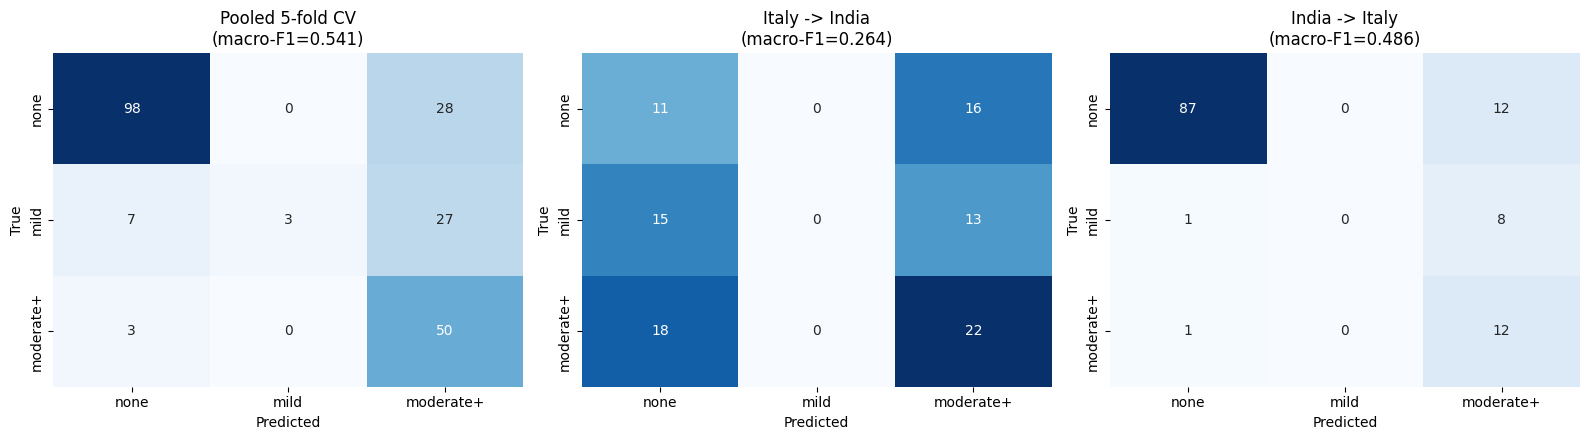

Saved confusion_matrices_v4.png to Drive.
Training-history pooled_macro_f1_corrected (last epoch before stop): 0.541
Best-checkpoint pooled_macro_f1_corrected (actual model used elsewhere): 0.540


In [9]:
import seaborn as sns
import re

pooled_true, pooled_pred = [], []
for fold, (model, hgb_stats) in cv_models_final.items():
    val_df = manifest_clean[manifest_clean['fold'] == fold]
    res = evaluate_v4(model, val_df, hgb_stats)
    pooled_true.extend(res['y_true'])
    pooled_pred.extend(res['y_pred'])

labels3 = ['none', 'mild', 'moderate+']

def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels3, yticklabels=labels3,
                ax=ax, cbar=False)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
plot_cm(pooled_true, pooled_pred, f'Pooled 5-fold CV\n(macro-F1={pooled_macro_f1:.3f})', axes[0])
plot_cm(result_it2in_final['y_true'], result_it2in_final['y_pred'], f'Italy -> India\n(macro-F1={f1_it2in:.3f})', axes[1])
plot_cm(result_in2it_final['y_true'], result_in2it_final['y_pred'], f'India -> Italy\n(macro-F1={f1_in2it:.3f})', axes[2])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/anemia/confusion_matrices_v4.png', dpi=150)
plt.show()
print("Saved confusion_matrices_v4.png to Drive.")

pooled_macro_f1_corrected = f1_score(pooled_true, pooled_pred, average='macro', zero_division=0)
print(f"Training-history pooled_macro_f1_corrected (last epoch before stop): {pooled_macro_f1:.3f}")
print(f"Best-checkpoint pooled_macro_f1_corrected (actual model used elsewhere): {pooled_macro_f1_corrected:.3f}")

# **31. Bootstrap confidence intervals on macro-F1**

In [10]:
def bootstrap_macro_f1(y_true, y_pred, n_boot=2000, seed=42):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rng = np.random.RandomState(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        scores.append(f1_score(y_true[idx], y_pred[idx], average='macro', zero_division=0))
    scores = np.array(scores)
    return np.percentile(scores, 2.5), np.percentile(scores, 97.5), scores

ci_pooled = bootstrap_macro_f1(pooled_true, pooled_pred)
ci_it2in  = bootstrap_macro_f1(result_it2in_final['y_true'], result_it2in_final['y_pred'])
ci_in2it  = bootstrap_macro_f1(result_in2it_final['y_true'], result_in2it_final['y_pred'])

print(f"Pooled CV       macro-F1 = {pooled_macro_f1:.3f}  95% CI [{ci_pooled[0]:.3f}, {ci_pooled[1]:.3f}]")
print(f"Italy -> India  macro-F1 = {f1_it2in:.3f}  95% CI [{ci_it2in[0]:.3f}, {ci_it2in[1]:.3f}]")
print(f"India -> Italy  macro-F1 = {f1_in2it:.3f}  95% CI [{ci_in2it[0]:.3f}, {ci_in2it[1]:.3f}]")



bootstrap_ci_summary = pd.DataFrame([
    {'setting': 'pooled_cv', 'macro_f1': pooled_macro_f1, 'ci_low': ci_pooled[0], 'ci_high': ci_pooled[1]},
    {'setting': 'Italy_to_India', 'macro_f1': f1_it2in, 'ci_low': ci_it2in[0], 'ci_high': ci_it2in[1]},
    {'setting': 'India_to_Italy', 'macro_f1': f1_in2it, 'ci_low': ci_in2it[0], 'ci_high': ci_in2it[1]},
])
bootstrap_ci_summary.to_csv('/content/drive/MyDrive/anemia/bootstrap_ci_macro_f1_v4.csv', index=False)
print(f"\n{bootstrap_ci_summary}")


Pooled CV       macro-F1 = 0.541  95% CI [0.475, 0.607]
Italy -> India  macro-F1 = 0.264  95% CI [0.197, 0.335]
India -> Italy  macro-F1 = 0.486  95% CI [0.416, 0.550]

          setting  macro_f1    ci_low   ci_high
0       pooled_cv  0.540578  0.474867  0.607313
1  Italy_to_India  0.264459  0.196504  0.335341
2  India_to_Italy  0.486288  0.415717  0.549834


# **32. Split-conformal prediction**

In [ ]:
from sklearn.model_selection import train_test_split

def coral_probs_from_logits(sigmoid_probs, num_classes):

    B = sigmoid_probs.size(0)
    class_probs = torch.zeros(B, num_classes, device=sigmoid_probs.device)
    class_probs[:, 0] = 1 - sigmoid_probs[:, 0]
    for k in range(1, num_classes-1):
        class_probs[:, k] = sigmoid_probs[:, k-1] - sigmoid_probs[:, k]
    class_probs[:, -1] = sigmoid_probs[:, -1]
    return torch.clamp(class_probs, min=1e-6)

def conformal_calibrate_model(model, calib_df, hgb_stats, alpha=0.1, norm_mode='clahe', num_classes=3):
    calib_ds = AnemiaEyeDataset3(calib_df, norm_mode=norm_mode, augment=False)
    calib_dl = DataLoader(calib_ds, batch_size=16, shuffle=False)
    model.eval()
    nonconformity_scores = []
    with torch.no_grad():
        for batch in calib_dl:
            img, meta = batch['image'].to(device), batch['meta'].to(device)
            sev = batch['severity'].to(device)
            ord_logits, _ = model(img, meta)
            class_probs = coral_probs_from_logits(torch.sigmoid(ord_logits), num_classes)
            true_probs = class_probs[torch.arange(len(sev)), sev]
            nonconformity_scores.extend((1 - true_probs).cpu().tolist())
    q_level = min(np.ceil((len(nonconformity_scores)+1)*(1-alpha)) / len(nonconformity_scores), 1.0)
    return np.quantile(nonconformity_scores, q_level)

def conformal_predict_sets_model(model, test_df, threshold, norm_mode='clahe', num_classes=3):
    test_ds = AnemiaEyeDataset3(test_df, norm_mode=norm_mode, augment=False)
    test_dl = DataLoader(test_ds, batch_size=16, shuffle=False)
    model.eval()
    pred_sets, covered, set_sizes, true_labels = [], [], [], []
    with torch.no_grad():
        for batch in test_dl:
            img, meta = batch['image'].to(device), batch['meta'].to(device)
            sev = batch['severity'].to(device)
            ord_logits, _ = model(img, meta)
            class_probs = coral_probs_from_logits(torch.sigmoid(ord_logits), num_classes)
            for i in range(img.size(0)):
                pred_set = [c for c in range(num_classes) if (1 - class_probs[i,c].item()) <= threshold]
                if not pred_set:
                    pred_set = [int(torch.argmax(class_probs[i]).item())]
                pred_sets.append(pred_set)
                covered.append(sev[i].item() in pred_set)
                set_sizes.append(len(pred_set))
                true_labels.append(sev[i].item())
    return {'coverage': np.mean(covered), 'set_sizes': set_sizes, 'pred_sets': pred_sets, 'y_true': true_labels}

india_df = manifest_clean[manifest_clean['Cohort']=='India']
india_calib, india_test = train_test_split(
    india_df, test_size=0.5, random_state=42, stratify=india_df['severity_3class']
)

threshold = conformal_calibrate_model(model_it2in_final, india_calib, hgb_stats_it_final, alpha=0.1)
result = conformal_predict_sets_model(model_it2in_final, india_test, threshold)

set_sizes = np.array(result['set_sizes'])
y_true = np.array(result['y_true'])
pred_sets = result['pred_sets']

confident_mask = set_sizes == 1
n_confident = confident_mask.sum()
n_referred = (~confident_mask).sum()
referral_rate = n_referred / len(set_sizes)

if n_confident > 0:
    confident_correct = sum(
        y_true[i] == pred_sets[i][0] for i in range(len(y_true)) if confident_mask[i]
    )
    confident_accuracy = confident_correct / n_confident
else:
    confident_accuracy = float('nan')

print(f"=== Conformal Reject-and-Refer, Italy-trained model tested on India ===")
print(f"Target coverage: 90%  |  Achieved coverage: {result['coverage']:.1%}")
print(f"Average prediction set size: {set_sizes.mean():.2f} / 3 classes")
print(f"\nReferral rate (set size > 1, 'refer to blood test'): {referral_rate:.1%}  ({n_referred}/{len(set_sizes)} patients)")
print(f"Confident predictions (set size == 1): {n_confident}/{len(set_sizes)} patients")
print(f"Accuracy on CONFIDENT predictions only: {confident_accuracy:.3f}")

result_forced = evaluate_v4(model_it2in_final, india_test, hgb_stats_it_final)
print(f"Standard forced-choice accuracy (same test set, no abstention): {result_forced['accuracy']:.3f}")

print(f"\n=== The clinical framing ===")
print(f"On the {n_confident} patients the model is confident about, it achieves {confident_accuracy:.1%} accuracy.")
print(f"On the remaining {n_referred} patients ({referral_rate:.1%}), it correctly identifies its own uncertainty")

# **34. Italy in-domain conformal comparison**

In [ ]:
italy_df = manifest_clean[manifest_clean['Cohort']=='Italy']
india_df = manifest_clean[manifest_clean['Cohort']=='India']
italy_calib, italy_test = train_test_split(
    italy_df, test_size=0.3, random_state=42, stratify=italy_df['severity_3class']
)

threshold_italy = conformal_calibrate_model(model_it2in_final, italy_calib, hgb_stats_it_final, alpha=0.1)
result_italy = conformal_predict_sets_model(model_it2in_final, italy_test, threshold_italy)

set_sizes_italy = np.array(result_italy['set_sizes'])
print(f"=== SAME model, tested on ITALY (in-domain) ===")
print(f"Achieved coverage: {result_italy['coverage']:.1%}")
print(f"Average prediction set size: {set_sizes_italy.mean():.2f} / 3 classes")
print(f"Referral rate (set size > 1): {(set_sizes_italy > 1).mean():.1%}")
print(f"Confident predictions (set size == 1): {(set_sizes_italy == 1).sum()}/{len(set_sizes_italy)}")

print(f"\n=== Comparison ===")
print(f"In-domain (Italy) avg set size:     {set_sizes_italy.mean():.2f}")
print(f"Cross-domain (India) avg set size:   {set_sizes.mean():.2f}")

# **35.  Richer conformal reporting: set-size breakdown + singleton rate**

In [ ]:
def set_size_breakdown(pred_sets_list):
    sizes = [len(s) for s in pred_sets_list]
    return {s: round(sizes.count(s)/len(sizes), 3) for s in [0,1,2,3]}

print("Italy-test (in-domain) set-size breakdown:", set_size_breakdown(result_italy['pred_sets']))
print("India (out-of-domain) set-size breakdown:", set_size_breakdown(result['pred_sets']))

it_sizes = np.array(result_italy['set_sizes'])
india_sizes = np.array(result['set_sizes'])
print(f"\nSingleton-set rate -- Italy-test: {(it_sizes==1).mean():.3f}   India: {(india_sizes==1).mean():.3f}")
print(f"Full-set rate (all 3 classes) -- Italy-test: {(it_sizes==3).mean():.3f}   India: {(india_sizes==3).mean():.3f}")

# **36. Per-class conformal coverage under domain shift**

In [ ]:
def per_class_coverage_from_result(res, class_names=['none', 'mild', 'moderate+']):
    y_true = np.array(res['y_true'])
    pred_sets = res['pred_sets']
    rows = []
    for c, name in enumerate(class_names):
        mask = y_true == c
        if mask.sum() == 0:
            rows.append({'class': name, 'coverage': float('nan'), 'n': 0}); continue
        covered = np.array([c in pred_sets[i] for i in np.where(mask)[0]])
        rows.append({'class': name, 'coverage': covered.mean(), 'n': int(mask.sum())})
    return pd.DataFrame(rows)

print("=== Italy-test (in-domain) per-class coverage ===")
cov_it_by_class = per_class_coverage_from_result(result_italy)
print(cov_it_by_class)

print("\n=== India (out-of-domain) per-class coverage ===")
cov_india_by_class = per_class_coverage_from_result(result)
print(cov_india_by_class)

print(f"\nTarget coverage for reference: 0.90")
mild_it = cov_it_by_class.set_index('class').loc['mild']
mild_in = cov_india_by_class.set_index('class').loc['mild']
covered = int(mild_it['coverage']*mild_it['n']) + int(mild_in['coverage']*mild_in['n'])
total = int(mild_it['n']) + int(mild_in['n'])
print(f"Mild-class coverage combined across both domains: {covered}/{total} = {covered/total:.3f}")

# **37. Binary (any-anemia) LOCO control:**

In [ ]:
manifest_binary = manifest_clean.copy()
manifest_binary['severity_3class'] = manifest_binary['anemic_binary']

print("=== Binary LOCO: Train Italy -> Test India ===")
model_it2in_bin, hgb_stats_it_bin = train_full_v4(manifest_binary[manifest_binary['Cohort']=='Italy'], num_classes=2, epochs=60)
result_it2in_bin = evaluate_v4(model_it2in_bin, manifest_binary[manifest_binary['Cohort']=='India'], hgb_stats_it_bin)
f1_it2in_bin = f1_score(result_it2in_bin['y_true'], result_it2in_bin['y_pred'], average='macro', zero_division=0)
print(f"Accuracy: {result_it2in_bin['accuracy']:.3f}, macro-F1: {f1_it2in_bin:.3f} (n={result_it2in_bin['n']})")
print(confusion_matrix(result_it2in_bin['y_true'], result_it2in_bin['y_pred']))

print("\n=== Binary LOCO: Train India -> Test Italy ===")
model_in2it_bin, hgb_stats_in_bin = train_full_v4(manifest_binary[manifest_binary['Cohort']=='India'], num_classes=2, epochs=60)
result_in2it_bin = evaluate_v4(model_in2it_bin, manifest_binary[manifest_binary['Cohort']=='Italy'], hgb_stats_in_bin)
f1_in2it_bin = f1_score(result_in2it_bin['y_true'], result_in2it_bin['y_pred'], average='macro', zero_division=0)
print(f"Accuracy: {result_in2it_bin['accuracy']:.3f}, macro-F1: {f1_in2it_bin:.3f} (n={result_in2it_bin['n']})")
print(confusion_matrix(result_in2it_bin['y_true'], result_in2it_bin['y_pred']))

print(f"\n=== 3-class vs. binary comparison (macro-F1) ===")
print(f"Italy->India  3-class={f1_it2in:.3f}  |  binary={f1_it2in_bin:.3f}")
print(f"India->Italy  3-class={f1_in2it:.3f}  |  binary={f1_in2it_bin:.3f}")

binary_loco_summary = pd.DataFrame([
    {'setting': 'Italy_to_India_binary', 'accuracy': result_it2in_bin['accuracy'], 'macro_f1': f1_it2in_bin},
    {'setting': 'India_to_Italy_binary', 'accuracy': result_in2it_bin['accuracy'], 'macro_f1': f1_in2it_bin},
])
binary_loco_summary.to_csv('/content/drive/MyDrive/anemia/binary_loco_results_v4.csv', index=False)
print(f"\n{binary_loco_summary}")


# **38. dumb mean-color baseline, LOCO-evaluated**

In [ ]:
from sklearn.linear_model import LogisticRegression

def mean_color_features(df):
    feats = []
    for p in df['palpebral_path']:
        roi = extract_roi(p, target_size=(224, 224))
        roi = preprocess_roi(roi, mode='clahe')
        feats.append(roi.reshape(-1, 3).mean(axis=0))
    return np.array(feats)

italy_df_full = manifest_clean[manifest_clean['Cohort']=='Italy']
india_df_full = manifest_clean[manifest_clean['Cohort']=='India']

X_italy, y_italy_c = mean_color_features(italy_df_full), italy_df_full['severity_3class'].values
X_india_c, y_india_c = mean_color_features(india_df_full), india_df_full['severity_3class'].values

def run_color_baseline(X_train, y_train, X_test, y_test, name):
    clf = LogisticRegression(class_weight='balanced', max_iter=2000, multi_class='multinomial')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = (y_pred == y_test).mean()
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    print(f"{name}: accuracy={acc:.3f}, macro-F1={f1:.3f} (n={len(y_test)})")
    print(confusion_matrix(y_test, y_pred, labels=[0, 1, 2]))
    return acc, f1

print("=== Mean-color logistic regression baseline (no deep learning) ===")
acc_c_it2in, f1_c_it2in = run_color_baseline(X_italy, y_italy_c, X_india_c, y_india_c, "Italy -> India (color-only)")
print()
acc_c_in2it, f1_c_in2it = run_color_baseline(X_india_c, y_india_c, X_italy, y_italy_c, "India -> Italy (color-only)")

print(f"\n=== Deep model vs. color-only baseline (macro-F1) ===")
print(f"Italy->India:  MobileNetV3={f1_it2in:.3f}   color-only={f1_c_it2in:.3f}")
print(f"India->Italy:  MobileNetV3={f1_in2it:.3f}   color-only={f1_c_in2it:.3f}")


# **39. Grad-CAM validation**

Sample 1: predicted class 2
Sample 2: predicted class 2
Sample 3: predicted class 2
Sample 4: predicted class 2
Sample 5: predicted class 2


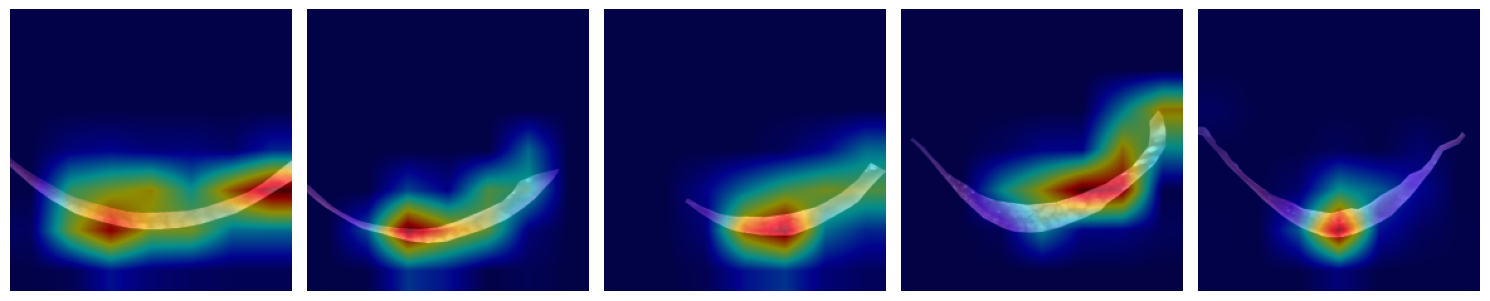

Saved Grad-CAM visualization to Drive.


In [22]:
!pip install grad-cam -q

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import os
import torch.nn as nn


class WrappedAnemiaNet(nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.model = original_model

        self.register_buffer('dummy_meta', torch.zeros(1, 2))

    def forward(self, x):

        meta = self.dummy_meta.repeat(x.size(0), 1).to(x.device)

        ord_logits, _ = self.model(x, meta)
        return ord_logits


def grad_cam_on_model(model, df, target_layer, device, num_samples=5):
    model.eval()
    wrapped_model = WrappedAnemiaNet(model).to(device)

    ds = AnemiaEyeDataset3(df, norm_mode='clahe', augment=False)
    dl = DataLoader(ds, batch_size=1, shuffle=True)

    cam = GradCAM(model=wrapped_model, target_layers=[target_layer])
    images, heatmaps = [], []

    for i, batch in enumerate(dl):
        if i >= num_samples:
            break
        img_tensor = batch['image'].to(device)


        ord_logits = wrapped_model(img_tensor)
        pred_class = CoralOrdinalHead.logits_to_label(ord_logits).item()

        grayscale_cam = cam(input_tensor=img_tensor, targets=None)
        grayscale_cam = grayscale_cam[0, :]


        img_np = img_tensor[0].cpu().numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)

        visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)
        images.append(visualization)
        heatmaps.append(grayscale_cam)
        print(f"Sample {i+1}: predicted class {pred_class}")

    return images, heatmaps

target_layer = model_it2in_final.backbone.features[-1]

images, _ = grad_cam_on_model(model_it2in_final, india_df, target_layer, device, num_samples=5)

if images:
    fig, axes = plt.subplots(1, len(images), figsize=(15, 4))
    for ax, img in zip(axes, images):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/anemia/gradcam_samples_it2in.png', dpi=150)
    plt.show()
    print("Saved Grad-CAM visualization to Drive.")
else:
    print("No images generated.")

# **40**

In [11]:
loco_summary_v4.loc[loco_summary_v4['setting']=='pooled_cv', 'macro_f1'] = pooled_macro_f1_corrected
loco_summary_v4.to_csv('/content/drive/MyDrive/anemia/loco_results_v4.csv', index=False)

# **41. Mild-class diagnostic**

In [ ]:
def coral_rank_score(logits):

    return torch.sigmoid(logits).sum(dim=1)

def plot_score_distribution(model, df, title, norm_mode='clahe'):
    ds = AnemiaEyeDataset3(df, norm_mode=norm_mode, augment=False)
    dl = DataLoader(ds, batch_size=16, shuffle=False, num_workers=2)
    model.eval()
    scores, labels = [], []
    with torch.no_grad():
        for batch in dl:
            img, meta = batch['image'].to(device), batch['meta'].to(device)
            ord_logits, _ = model(img, meta)
            scores.extend(coral_rank_score(ord_logits).cpu().tolist())
            labels.extend(batch['severity'].tolist())
    scores, labels = np.array(scores), np.array(labels)
    fig, ax = plt.subplots(figsize=(7,4))
    for c, name in enumerate(['none','mild','moderate+']):
        vals = scores[labels==c]
        if len(vals):
            ax.hist(vals, bins=15, alpha=0.55, label=f'{name} (n={len(vals)})')
    ax.set_xlabel('Ordinal severity score (0=none .. 2=moderate+)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()
    overlap_none_mild = np.mean(np.abs(scores[labels==0].mean() - scores[labels==1].mean())) if (labels==1).any() else float('nan')
    print(f"Mean score -- none: {scores[labels==0].mean():.3f}, mild: {scores[labels==1].mean():.3f}, "
          f"moderate+: {scores[labels==2].mean():.3f}" if (labels==2).any() else "")
    return scores, labels

_ = plot_score_distribution(cv_models_final[0][0], manifest_clean[manifest_clean['fold']==0],
                             title='Pooled CV fold 0 (val set): ordinal score by true class')

_ = plot_score_distribution(model_it2in_final, manifest_clean[manifest_clean['Cohort']=='India'],
                             title='Italy->India LOCO: ordinal score by true class (India)')


# **41.b Tissue-Masked Training Experiment**

In [12]:
print("\n" + "="*60)
print("TISSUE-MASKED TRAINING: Italy -> India")
print("="*60)


model_it2in_masked, hgb_it_masked = train_full_v4(
    manifest_clean[manifest_clean['Cohort']=='Italy'],
    epochs=60,
    use_masking=True
)
res_it2in_masked = evaluate_v4(model_it2in_masked,
                               manifest_clean[manifest_clean['Cohort']=='India'],
                               hgb_it_masked,
                               use_masking=True)
f1_it2in_masked = f1_score(res_it2in_masked['y_true'], res_it2in_masked['y_pred'],
                           average='macro', zero_division=0)

print(f"\nItaly -> India WITH tissue masking:")
print(f"  Accuracy = {res_it2in_masked['accuracy']:.3f}")
print(f"  Macro-F1 = {f1_it2in_masked:.3f}")
print(f"  (Original without masking: macro-F1 = {f1_it2in:.3f})")
print("\nConfusion matrix:")
print(confusion_matrix(res_it2in_masked['y_true'], res_it2in_masked['y_pred']))


torch.save(model_it2in_masked.state_dict(),
           '/content/drive/MyDrive/anemia/model_it2in_masked.pt')

print("\n" + "="*60)
print("TISSUE-MASKED TRAINING: India -> Italy")
print("="*60)

model_in2it_masked, hgb_in_masked = train_full_v4(
    manifest_clean[manifest_clean['Cohort']=='India'],
    epochs=60,
    use_masking=True
)
res_in2it_masked = evaluate_v4(model_in2it_masked,
                               manifest_clean[manifest_clean['Cohort']=='Italy'],
                               hgb_in_masked,
                               use_masking=True)
f1_in2it_masked = f1_score(res_in2it_masked['y_true'], res_in2it_masked['y_pred'],
                           average='macro', zero_division=0)

print(f"\nIndia -> Italy WITH tissue masking:")
print(f"  Accuracy = {res_in2it_masked['accuracy']:.3f}")
print(f"  Macro-F1 = {f1_in2it_masked:.3f}")
print(f"  (Original without masking: macro-F1 = {f1_in2it:.3f})")
print("\nConfusion matrix:")
print(confusion_matrix(res_in2it_masked['y_true'], res_in2it_masked['y_pred']))

torch.save(model_in2it_masked.state_dict(),
           '/content/drive/MyDrive/anemia/model_in2it_masked.pt')


summary_masked = pd.DataFrame([
    {'setting': 'Italy->India', 'masked': f1_it2in_masked, 'original': f1_it2in},
    {'setting': 'India->Italy', 'masked': f1_in2it_masked, 'original': f1_in2it}
])
print("\n=== Summary of masking effect ===")
print(summary_masked)
summary_masked.to_csv('/content/drive/MyDrive/anemia/masking_effect.csv', index=False)


TISSUE-MASKED TRAINING: Italy -> India
  epoch 0: train loss=1.255
  epoch 10: train loss=0.780
  epoch 20: train loss=0.453
  epoch 30: train loss=0.708
  epoch 40: train loss=0.573
  epoch 50: train loss=0.568

Italy -> India WITH tissue masking:
  Accuracy = 0.337
  Macro-F1 = 0.276
  (Original without masking: macro-F1 = 0.264)

Confusion matrix:
[[11  0 16]
 [16  1 11]
 [19  1 20]]

TISSUE-MASKED TRAINING: India -> Italy
  epoch 0: train loss=0.821
  epoch 10: train loss=0.900
  epoch 20: train loss=0.852
  epoch 30: train loss=0.691
  epoch 40: train loss=0.794
  epoch 50: train loss=0.624

India -> Italy WITH tissue masking:
  Accuracy = 0.777
  Macro-F1 = 0.429
  (Original without masking: macro-F1 = 0.486)

Confusion matrix:
[[87  0 12]
 [ 7  0  2]
 [ 6  0  7]]

=== Summary of masking effect ===
        setting    masked  original
0  Italy->India  0.275936  0.264459
1  India->Italy  0.428712  0.486288


# **41.c Domain Adversarial Training (DANN) for Italy->India**

In [ ]:
class GradientReversal(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.alpha, None

def train_full_v4_dann(train_df, target_df, norm_mode='clahe', epochs=60,
                       batch_size=16, lr=5e-5, lambda_reg=0.5, lambda_dann=0.1,
                       num_classes=3, seed=42, use_masking=False):
    torch.manual_seed(seed); np.random.seed(seed)
    hgb_mean, hgb_std = get_hgb_stats(train_df)

    train_ds = AnemiaEyeDataset3(train_df, norm_mode=norm_mode, augment=True, use_masking=use_masking)
    target_ds = AnemiaEyeDataset3(target_df, norm_mode=norm_mode, augment=False, use_masking=use_masking)
    sampler = make_balanced_sampler_3class(train_df)
    train_dl = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=2)
    target_dl = DataLoader(target_ds, batch_size=batch_size, shuffle=True, num_workers=2)

    counts = train_df['severity_3class'].value_counts().reindex(range(num_classes), fill_value=1)
    class_weights = torch.tensor((1.0 / counts.values), dtype=torch.float32)
    class_weights = (class_weights / class_weights.sum() * num_classes).to(device)

    model = AnemiaNet(num_severity_classes=num_classes).to(device)

    domain_classifier = nn.Sequential(
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(64, 1)
    ).to(device)

    opt = AdamW(list(model.parameters()) + list(domain_classifier.parameters()), lr=lr, weight_decay=1e-4)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    huber = nn.HuberLoss(delta=1.0)
    bce = nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        model.train()
        domain_classifier.train()
        target_iter = iter(target_dl)
        for step, batch in enumerate(train_dl):
            try:
                tgt_batch = next(target_iter)
            except StopIteration:
                target_iter = iter(target_dl)
                tgt_batch = next(target_iter)

            img, meta = batch['image'].to(device), batch['meta'].to(device)
            sev, hgb = batch['severity'].to(device), batch['hgb'].to(device)
            tgt_img, tgt_meta = tgt_batch['image'].to(device), tgt_batch['meta'].to(device)

            hgb_z = (hgb - hgb_mean) / hgb_std

            opt.zero_grad()


            feat = model.backbone(img)
            if feat.ndim > 2: feat = feat.flatten(1)
            src_fused = model.fusion(torch.cat([feat, meta], dim=1))
            ord_logits = model.ordinal_head(src_fused)
            hgb_pred_z = model.regression_head(src_fused).squeeze(-1)


            tgt_feat = model.backbone(tgt_img)
            if tgt_feat.ndim > 2: tgt_feat = tgt_feat.flatten(1)
            tgt_fused = model.fusion(torch.cat([tgt_feat, tgt_meta], dim=1))


            task_loss = coral_loss_weighted(ord_logits, sev, num_classes, class_weights) + lambda_reg * huber(hgb_pred_z, hgb_z)


            alpha = 2.0 / (1.0 + np.exp(-10.0 * epoch / epochs)) - 1.0
            src_domain = GradientReversal.apply(src_fused, alpha)
            tgt_domain = GradientReversal.apply(tgt_fused, alpha)
            domain_pred_src = domain_classifier(src_domain).squeeze(-1)
            domain_pred_tgt = domain_classifier(tgt_domain).squeeze(-1)
            domain_labels_src = torch.zeros_like(domain_pred_src)
            domain_labels_tgt = torch.ones_like(domain_pred_tgt)
            domain_loss = bce(domain_pred_src, domain_labels_src) + bce(domain_pred_tgt, domain_labels_tgt)

            loss = task_loss + lambda_dann * domain_loss
            loss.backward(); opt.step()

        sched.step()
        if epoch % 10 == 0:
            print(f"  epoch {epoch}: task={task_loss.item():.3f}, domain={domain_loss.item():.3f}")

    return model, (hgb_mean, hgb_std)


print("\n" + "="*60)
print("DOMAIN ADVERSARIAL TRAINING: Italy -> India")
print("="*60)

model_dann, hgb_dann = train_full_v4_dann(
    manifest_clean[manifest_clean['Cohort']=='Italy'],
    manifest_clean[manifest_clean['Cohort']=='India'],
    epochs=60,
    use_masking=False
)
res_dann = evaluate_v4(model_dann,
                       manifest_clean[manifest_clean['Cohort']=='India'],
                       hgb_dann,
                       use_masking=False)
f1_dann = f1_score(res_dann['y_true'], res_dann['y_pred'], average='macro', zero_division=0)

print(f"\nItaly -> India WITH Domain Adversarial Training:")
print(f"  Accuracy = {res_dann['accuracy']:.3f}")
print(f"  Macro-F1 = {f1_dann:.3f}")
print(f"  (Original without DANN: macro-F1 = {f1_it2in:.3f})")
print("\nConfusion matrix:")
print(confusion_matrix(res_dann['y_true'], res_dann['y_pred']))

torch.save(model_dann.state_dict(), '/content/drive/MyDrive/anemia/model_dann_it2in.pt')